In [1]:
from google.colab import drive
drive.mount('/content/drive')
import cv2
import matplotlib.pyplot as plt

Mounted at /content/drive


In [2]:
from time import sleep

In [3]:
# Without TQDM
s = 0
for i in range(10):
    s += i
    sleep(0.2)
print(s)

45


In [4]:
# With TQDM
from tqdm import tqdm

s = 0
for i in tqdm(range(10)):
    s += i
    sleep(0.2)
print(s)

100%|██████████| 10/10 [00:02<00:00,  4.97it/s]

45


## Motivation


### Eigendecomposition

The **eigendecomposition** of some matrix $A$ is

$A = V \Lambda V^{-1}$

Where:

* As in examples above, $V$ is the concatenation of all the eigenvectors of $A$
* $\Lambda$ (upper-case $\lambda$) is the diagonal matrix diag($\lambda$). Note that the convention is to arrange the lambda values in descending order; as a result, the first eigenvalue (and its associated eigenvector) may be a primary characteristic of the matrix $A$.

In [5]:
import numpy as np
import torch

In [6]:
A = np.array([[4, 2], [-5, -3]])
A

array([[ 4,  2],
       [-5, -3]])

In [7]:
lambdas, V = np.linalg.eig(A)

In [8]:
V

array([[ 0.70710678, -0.37139068],
       [-0.70710678,  0.92847669]])

In [9]:
Vinv = np.linalg.inv(V)
Vinv

array([[2.3570226 , 0.94280904],
       [1.79505494, 1.79505494]])

In [10]:
Lambda = np.diag(lambdas)
Lambda

array([[ 2.,  0.],
       [ 0., -1.]])

Confirm that $A = V \Lambda V^{-1}$:

In [11]:
np.dot(V, np.dot(Lambda, Vinv))

array([[ 4.,  2.],
       [-5., -3.]])

Eigendecomposition is not possible with all matrices. And in some cases where it is possible, the eigendecomposition involves complex numbers instead of straightforward real numbers.

In machine learning, however, we are typically working with real symmetric matrices, which can be conveniently and efficiently decomposed into real-only eigenvectors and real-only eigenvalues. If $A$ is a real symmetric matrix then...

$A = Q \Lambda Q^T$

...where $Q$ is analogous to $V$ from the previous equation except that it's special because it's an orthogonal matrix.

In [12]:
A = np.array([[1, 2], [2, 1]])
A

array([[1, 2],
       [2, 1]])

In [13]:
lambdas, Q = np.linalg.eig(A)

In [14]:
lambdas

array([ 3., -1.])

In [15]:
Lambda = np.diag(lambdas)
Lambda

array([[ 3.,  0.],
       [ 0., -1.]])

In [16]:
Q

array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]])

Let's confirm $A = Q \Lambda Q^T$:

In [17]:
np.dot(Q, np.dot(Lambda, Q.T))

array([[1., 2.],
       [2., 1.]])

(As a quick aside, we can demostrate that $Q$ is an orthogonal matrix because $Q^TQ = QQ^T = I$.)

In [18]:
np.dot(Q.T, Q)

array([[1.00000000e+00, 2.23711432e-17],
       [2.23711432e-17, 1.00000000e+00]])

In [19]:
np.dot(Q, Q.T)

array([[ 1.00000000e+00, -2.23711432e-17],
       [-2.23711432e-17,  1.00000000e+00]])

**Exercises**:

1. Use PyTorch to decompose the matrix $P$ (below) into its components $V$, $\Lambda$, and $V^{-1}$. Confirm that $P = V \Lambda V^{-1}$.
2. Use PyTorch to decompose the symmetric matrix $S$ (below) into its components $Q$, $\Lambda$, and $Q^T$. Confirm that $S = Q \Lambda Q^T$.

In [20]:
P = torch.tensor([[25, 2, -5], [3, -2, 1], [5, 7, 4.]])
P

tensor([[25.,  2., -5.],
        [ 3., -2.,  1.],
        [ 5.,  7.,  4.]])

In [21]:
S = torch.tensor([[25, 2, -5], [2, -2, 1], [-5, 1, 4.]])
S

tensor([[25.,  2., -5.],
        [ 2., -2.,  1.],
        [-5.,  1.,  4.]])


### Singular Value Decomposition (SVD)
==================================


Previously, we explored a class of vectors whose directions were left unchanged by a matrix. We found that, for any **square** matrix, if there existed $n$ linearly independent eigenvectors, we could diagonalize $\bf A$ into the form  $\bf{AX = XD} $, where  $\bf X $ is a basis of  $\mathbb{R}^n $, where  $\bf{Ax_i = \lambda_ix_i} $.

A more general factorization is, for **any**  $m \times n $ matrix, there exists a singular value decomposition in the form  $\bf{AV = U{\Sigma}} $ or  $\bf{A=U{\Sigma}V^T} $. To result in this composition, we require  $\bf U $ as an orthogonal basis of  $\mathbb{R}^m $,  $\bf V $ as an orthogonal basis of  $\mathbb{R}^n $, and  $\bf{\Sigma} $ as an  $m \times n $ diagonal matrix, where  $\bf{Av_i = \sigma_iu_i} $.

*    $\bf U $ is composed of the eigenvectors of  $\bf{AA^T} $ as its columns.
*    $\bf V $ is composed of the eigenvectors of  $\bf{A^TA} $ as its columns.
*    $\bf \Sigma $ is a diagonal matrix composed of square roots of the eigenvalues of  $\bf{A^TA} $ (or  $\bf{AA^T} $), called singular values.
*    $\bf{A^TA} $ and  $\bf{AA^T} $ have the same positive eigenvalues, so the square roots of the eigenvalues are also the same.
*   The diagonal of  $\bf \Sigma $ is ordered by non-increasing singular values and the columns of  $\bf U $,  $\bf V $ are ordered respectively.

In addition, we define a reduced form:  ${\bf A} = {\bf U_{R}} {\bf \Sigma_{R}} {\bf V_R}^T $ where  ${\bf U_R} $ is an  $m \times k $ matrix,  ${\bf V_R} $ is an  $n \times k $ matrix, and  ${\bf \Sigma_{R}} $ is an  $k \times k $ diagonal matrix. Here,  $k = \min(m,n) $.


Singular Value Decomposition
----------------------------

An  $m \times n $ real matrix  ${\bf A} $ has a singular value decomposition of the form

\\[{\bf A} = {\bf U} {\bf \Sigma} {\bf V}^T\\]

where  ${\bf U} $ is an  $m \times m $ orthogonal matrix,  ${\bf V} $ is an  $n \times n $ orthogonal matrix, and  ${\bf \Sigma} $ is an  $m \times n $ diagonal matrix. Specifically,

*    ${\bf U} $ is an  $m \times m $ orthogonal matrix whose columns are eigenvectors of  ${\bf A} {\bf A}^T $, called the **left singular vectors** of  ${\bf A} $.

\\[\mathbf{A}\mathbf{A}^T = ({\bf U} {\bf \Sigma} {\bf V}^T)({\bf U} {\bf \Sigma} {\bf V}^T)^T\\] \\[\hspace{2cm} ({\bf U} {\bf \Sigma} {\bf V}^T) ({\bf V}^T)^T {\bf \Sigma}^T {\bf U}^T = {\bf U} {\bf \Sigma} ({\bf V}^T {\bf V}) {\bf \Sigma}^T {\bf U}^T = {\bf U} ({\bf \Sigma} {\bf \Sigma}^T) {\bf U}^T\\]

Hence,  $\bf{AA^T=U\Sigma^2U^T} $, which is a diagonalization, where the columns of U are linearly independent.

*    ${\bf V} $ is an  $n \times n $ orthogonal matrix whose columns are eigenvectors of  ${\bf A}^T {\bf A} $, called the **right singular vectors** of  ${\bf A} $.

\\[\mathbf{A}^T\mathbf{A} = ({\bf U} {\bf \Sigma} {\bf V}^T)^T ({\bf U} {\bf \Sigma} {\bf V}^T)\\] \\[= {\bf V} ({\bf \Sigma}^T {\bf \Sigma}) {\bf V}^T\\]

Hence,  $\bf{A^TA=V\Sigma^2V^T} $, which is a diagonalization, where the columns of V are linearly independent.

*    ${\bf \Sigma} $ is an  $m \times n $ diagonal matrix, composed of the square root of the eigenvalues of  $A^TA $, in the form:

\\[\begin{eqnarray} {\bf \Sigma} = \begin{bmatrix} \sigma_1 & & \\ & \ddots & \\ & & \sigma_s \\ 0 & & 0 \\ \vdots & \ddots & \vdots \\ 0 & & 0 \end{bmatrix} \text{when } m > n, \; \text{and} \; {\bf \Sigma} = \begin{bmatrix} \sigma_1 & & & 0 & \dots & 0 \\ & \ddots & & & \ddots &\\ & & \sigma_s & 0 & \dots & 0 \\ \end{bmatrix} \text{when} \, m < n. \end{eqnarray}\\]

where  $k = \min(m,n) $ and  $\sigma_1 \ge \sigma_2 \dots \ge \sigma_s \ge 0 $. The diagonal entries are called the _singular_ values of  ${\bf A} $.

#### Obtaining Singular Values

Note that the matrices  $\bf{A^TA} $ and  $\bf{AA^T} $ always have the same non-zero eigenvalues. In addition, they are both positive semi-definite (defined:  $\mathbf{x^{T}Bx} \geq 0 \quad \forall \mathbf{x} \neq 0 $). As the eigenvalues of positive semi-definite matrices are always non-negative, **singular values are always non-negative**.

If  $\mathbf{A}^T\mathbf{x} \ne 0 $, then  $\mathbf{A}^T\mathbf{A} $ and  $\mathbf{A}\mathbf{A}^T $ both have the same eigenvalues:

\\[\mathbf{A}\mathbf{A}^T\mathbf{x} = \lambda \mathbf{x}\\] \\[\mathbf{A}^T\mathbf{A}\mathbf{A}^T\mathbf{x} = \mathbf{A}^T \lambda \mathbf{x}\\] \\[\mathbf{A}^T\mathbf{A}(\mathbf{A}^T\mathbf{x}) = \lambda (\mathbf{A}^T\mathbf{x})\\]

Time Complexity
---------------

The time-complexity for computing the SVD factorization of an arbitrary  $m \times n $ matrix is $\mathcal{O}(m^2n + n^3) $


Reduced SVD
-----------

The SVD factorization of a non-square matrix  ${\bf A} $ of size  $m \times n $ can be represented in a reduced format:

*   For  $m \ge n $:  ${\bf U} $ is  $m \times n $,  ${\bf \Sigma} $ is  $n \times n $, and  ${\bf V} $ is  $n \times n $
*   For  $m \le n $:  ${\bf U} $ is  $m \times m $,  ${\bf \Sigma} $ is  $m \times m $, and  ${\bf V} $ is  $n \times m $ (note if  ${\bf V} $ is  $n \times m $, then  ${\bf V}^T $ is  $m \times n $)


In general, we will represent the reduced SVD as:

\\[{\bf A} = {\bf U}_R {\bf \Sigma}_R {\bf V}_R^T\\]

where  ${\bf U}_R $ is a  $m \times k $ matrix,  ${\bf V}_R $ is a  $n \times k $ matrix,  ${\bf \Sigma}_R $ is a  $k \times k $ matrix, and  $k = \min(m,n) $.

Example: Computing the SVD
--------------------------

We begin with the following non-square matrix,  ${\bf A} $

\\[ {\bf A} = \left[ \begin{array}{ccc} 3 & 2 & 3 \\ 8 & 8 & 2 \\ 8 & 7 & 4 \\ 1 & 8 & 7 \\ 6 & 4 & 7 \\ \end{array} \right] \\]

and we will compute the reduced form of the SVD (where here  $s = 3 $):

(1) Compute  ${\bf A}^T {\bf A} $:

\\[{\bf A}^T {\bf A} = \left[ \begin{array}{ccc} 174 & 158 & 106 \\ 158 & 197 & 134 \\ 106 & 134 & 127 \\ \end{array} \right]\\]

(2) Compute the eigenvectors and eigenvalues of  ${\bf A}^T {\bf A} $:

\\[\lambda_1 = 437.479, \quad \lambda_2 = 42.6444, \quad \lambda_3 = 17.8766, \\ \boldsymbol{v}_1 = \begin{bmatrix} 0.585051 \\ 0.652648 \\ 0.481418\end{bmatrix}, \quad \boldsymbol{v}_2 = \begin{bmatrix} -0.710399 \\ 0.126068 \\ 0.692415 \end{bmatrix}, \quad \boldsymbol{v}_3 = \begin{bmatrix} 0.391212 \\ -0.747098 \\ 0.537398 \end{bmatrix}\\]

(3) Construct  ${\bf V}_R $ from the eigenvectors of  ${\bf A}^T {\bf A} $:

\\[ {\bf V}_R = \left[ \begin{array}{ccc} 0.585051 & -0.710399 & 0.391212 \\ 0.652648 & 0.126068 & -0.747098 \\ 0.481418 & 0.692415 & 0.537398 \\ \end{array} \right]. \\]

(4) Construct  ${\bf \Sigma}_R $ from the square roots of the eigenvalues of  ${\bf A}^T {\bf A} $:

\\[ {\bf \Sigma}_R = \begin{bmatrix} 20.916 & 0 & 0 \\ 0 & 6.53207 & 0 \\ 0 & 0 & 4.22807 \end{bmatrix} \\]

(5) Find  ${\bf U} $ by solving  ${\bf U}{\bf\Sigma} = {\bf A}{\bf V} $. For our reduced case, we can find  ${\bf U}_R = {\bf A}{\bf V}_R {\bf \Sigma}_R^{-1} $. You could also find  ${\bf U} $ by computing the eigenvectors of  ${\bf AA}^T $.

\\[{\bf U} = \overbrace{\left[ \begin{array}{ccc} 3 & 2 & 3 \\ 8 & 8 & 2 \\ 8 & 7 & 4 \\ 1 & 8 & 7 \\ 6 & 4 & 7 \\ \end{array} \right]}^{A} \overbrace{\left[ \begin{array}{ccc} 0.585051 & -0.710399 & 0.391212 \\ 0.652648 & 0.126068 & -0.747098 \\ 0.481418 & 0.692415 & 0.537398 \\ \end{array} \right]}^{V} \overbrace{\left[ \begin{array}{ccc} 0.047810 & 0.0 & 0.0 \\ 0.0 & 0.153133 & 0.0 \\ 0.0 & 0.0 & 0.236515 \\ \end{array} \right]}^{\Sigma^{-1}}\\] \\[{\bf U} = \left[ \begin{array}{ccc} 0.215371 & 0.030348 & 0.305490 \\ 0.519432 & -0.503779 & -0.419173 \\ 0.534262 & -0.311021 & 0.011730 \\ 0.438715 & 0.787878 & -0.431352\\ 0.453759 & 0.166729 & 0.738082\\ \end{array} \right]\\]

We obtain the following singular value decomposition for  ${\bf A} $:

\\[ \overbrace{\left[ \begin{array}{ccc} 3 & 2 & 3 \\ 8 & 8 & 2 \\ 8 & 7 & 4 \\ 1 & 8 & 7 \\ 6 & 4 & 7 \\ \end{array} \right]}^{A} = \overbrace{\left[ \begin{array}{ccc} 0.215371 & 0.030348 & 0.305490 \\ 0.519432 & -0.503779 & -0.419173 \\ 0.534262 & -0.311021 & 0.011730 \\ 0.438715 & 0.787878 & -0.431352\\ 0.453759 & 0.166729 & 0.738082\\ \end{array} \right]}^{U} \overbrace{\left[ \begin{array}{ccc} 20.916 & 0 & 0 \\ 0 & 6.53207 & 0 \\ 0 & 0 & 4.22807 \\ \end{array} \right]}^{\Sigma} \overbrace{\left[ \begin{array}{ccc} 0.585051 & 0.652648 & 0.481418 \\ -0.710399 & 0.126068 & 0.692415\\ 0.391212 & -0.747098 & 0.537398\\ \end{array} \right]}^{V^T} \\]

Recall that we computed the _reduced_ SVD factorization (i.e.  ${\bf \Sigma} $ is square,  ${\bf U} $ is non-square) here.

Rank, null space and range of a matrix
--------------------------------------

Suppose  ${\bf A} $ is a  $m \times n $ matrix where  $m > n $ (without loss of generality):

\\[{\bf A}= {\bf U\Sigma V}^{T} = \begin{bmatrix}\vert & & \vert & & \vert \\ \vert & & \vert & & \vert \\ {\bf u}_1 & \cdots & {\bf u}_n & \cdots & {\bf u}_m\\ \vert & & \vert & & \vert \\\vert & & \vert & & \vert \end{bmatrix} \begin{bmatrix} \sigma_1 & & \\ & \ddots & \\ & & \sigma_n \\ & \vdots & \\ -& 0& -\end{bmatrix} \begin{bmatrix} - & {\bf v}_1^T & - \\ & \vdots & \\ - & {\bf v}_n^T & - \end{bmatrix}\\]

We can re-write the above as:

\\[{\bf A} = \begin{bmatrix}\vert & & \vert \\ \vert & & \vert \\ {\bf u}_1 & \cdots & {\bf u}_n \\ \vert & & \vert \\ \vert & & \vert \end{bmatrix} \begin{bmatrix} - & \sigma_1 {\bf v}_1^T & - \\ & \vdots & \\ - & \sigma_n{\bf v}_n^T & - \end{bmatrix}\\]

Furthermore, the product of two matrices can be written as a sum of outer products:

\\[{\bf A} = \sigma_1 {\bf u}_1 {\bf v}_1^T + \sigma_2 {\bf u}_2 {\bf v}_2^T + ... + \sigma_n {\bf u}_n {\bf v}_n^T\\]

For a general rectangular matrix, we have:

\\[{\bf A} = \sum_{i=1}^{s} \sigma_i {\bf u}_i {\bf v}_i^T\\]

where  $s = \min(m,n) $.

If  ${\bf A} $ has  $s $ non-zero singular values, the matrix is full rank, i.e.  $\text{rank}({\bf A}) = s $.

If  ${\bf A} $ has  $r $ non-zero singular values, and  $r < s $, the matrix is rank deficient, i.e.  $\text{rank}({\bf A}) = r $.

In other words, the rank of  ${\bf A} $ equals the number of non-zero singular values which is the same as the number of non-zero diagonal elements in  ${\bf \Sigma} $.

Rounding errors may lead to small but non-zero singular values in a rank deficient matrix. Singular values that are smaller than a given tolerance are assumed to be numerically equivalent to zero, defining what is sometimes called the effective rank.

The right-singular vectors (columns of  ${\bf V} $) corresponding to vanishing singular values of  ${\bf A} $ span the null space of  ${\bf A} $, i.e. null( ${\bf A} $) = span{ ${\bf v}_{r+1} $,  ${\bf v}_{r+2} $, …,  ${\bf v}_{n} $}.

The left-singular vectors (columns of  ${\bf U} $) corresponding to the non-zero singular values of  ${\bf A} $ span the range of  ${\bf A} $, i.e. range( ${\bf A} $) = span{ ${\bf u}_{1} $,  ${\bf u}_{2} $, …,  ${\bf u}_{r} $}.

#### Example:

\\[{\bf A} = \left[ \begin{array}{cccc} \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} & 0 & 0 \\ \frac{1}{\sqrt{2}}2 &\frac{1}{\sqrt{2}} & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{array} \right] \left[ \begin{array}{ccc} 14 & 0 & 0 \\ 0 & 14 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{array} \right] \left[ \begin{array}{ccc} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{array} \right]\\]

The rank of  ${\bf A} $ is 2.

The vectors  $\left[ \begin{array}{c} \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \\ 0 \\ 0 \end{array} \right] $ and  $\left[ \begin{array}{c} -\frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \\ 0 \\ 0 \end{array} \right] $ provide an orthonormal basis for the range of  ${\bf A} $.

The vector  $\left[ \begin{array}{c} 0 \\ 0\\ 1 \end{array} \right] $ provides an orthonormal basis for the null space of  ${\bf A} $.

(Moore-Penrose) Pseudoinverse
-----------------------------

If the matrix  ${\bf \Sigma} $ is rank deficient, we cannot get its inverse. We define instead the pseudoinverse:

\\[({\bf \Sigma}^+)_{ii} = \begin{cases} \frac{1}{\sigma_i} & \sigma_i \neq 0\\ 0 & \sigma_i = 0 \end{cases}\\]

For a general non-square matrix  ${\bf A} $ with known SVD ( ${\bf A} = {\bf U\Sigma V}^T $), the pseudoinverse is defined as:

\\[{\bf A}^{+} = {\bf V\Sigma}^{+}{\bf U}^T\\]

For example, if we consider a  $m \times n $ full rank matrix where  $m > n $:

\\[{\bf A}^{+}= \begin{bmatrix} \vert & ... & \vert \\ {\bf v}_1 & ... & {\bf v}_n\\ \vert & ... & \vert \end{bmatrix} \begin{bmatrix} 1/\sigma_1 & & & 0 & \dots & 0 \\ & \ddots & & & \ddots &\\ & & 1/\sigma_n & 0 & \dots & 0 \\ \end{bmatrix} \begin{bmatrix}\vert & & \vert & & \vert \\ \vert & & \vert & & \vert \\ {\bf u}_1 & \cdots & {\bf u}_n & \cdots & {\bf u}_m\\ \vert & & \vert & & \vert \\\vert & & \vert & & \vert \end{bmatrix}^T\\]

Euclidean norm of matrices
--------------------------

The induced 2-norm of a matrix  ${\bf A} $ can be obtained using the SVD of the matrix :

\\[\begin{align} \| {\bf A} \|_2 &= \max_{\|\mathbf{x}\|=1} \|\mathbf{A x}\| = \max_{\|\mathbf{x}\|=1} \|\mathbf{U \Sigma V}^T {\bf x}\| \\ & =\max_{\|\mathbf{x}\|=1} \|\mathbf{ \Sigma V}^T {\bf x}\| = \max_{\|\mathbf{V}^T{\bf x}\|=1} \|\mathbf{ \Sigma V}^T {\bf x}\| =\max_{\|y\|=1} \|\mathbf{ \Sigma} y\| \end{align}\\]

And hence,

\\[\| {\bf A} \|_2= \sigma_1\\]

In the above equations, all the notations for the norm  $\| . \| $ refer to the  $p=2 $ Euclidean norm, and we used the fact that  ${\bf U} $ and  ${\bf V} $ are orthogonal matrices and hence  $\|{\bf U}\|_2 = \|{\bf V}\|_2 = 1 $.

#### Example:

We begin with the following non-square matrix  ${\bf A} $:

\\[{\bf A} = \left[ \begin{array}{ccc} 3 & 2 & 3 \\ 8 & 8 & 2 \\ 8 & 7 & 4 \\ 1 & 8 & 7 \\ 6 & 4 & 7 \\ \end{array} \right].\\]

The matrix of singular values,  ${\bf \Sigma} $, computed from the SVD factorization is:

\\[ \Sigma = \left[ \begin{array}{ccc} 20.916 & 0 & 0 \\ 0 & 6.53207 & 0 \\ 0 & 0 & 4.22807 \\ \end{array} \right]. \\]

Consequently the 2-norm of  ${\bf A} $ is

\\[ \|{\bf A}\|_2 = 20.916.\\]

Euclidean norm of the inverse of matrices
-----------------------------------------

Following the same derivation as above, we can show that for a full rank  $n \times n $ matrix we have:

\\[\| {\bf A}^{-1} \|_2= \frac{1}{\sigma_n}\\]

where  ${\sigma_n} $ is the smallest singular value.

For non-square matrices, we can use the definition of the pseudoinverse (regardless of the rank):

\\[\| {\bf A}^{+} \|_2= \frac{1}{\sigma_r}\\]

where  ${\sigma_r} $ is the smallest **non-zero** singular value. Note that for a full rank square matrix, we have  $\| {\bf A}^{+} \|_2 = \| {\bf A}^{-1} \|_2 $. An exception of the definition above is the zero matrix. In this case,  $\| {\bf A}^{+} \|_2 = 0 $

2-Norm Condition Number
-----------------------

The 2-norm condition number of a matrix  ${\bf A} $ is given by the ratio of its largest singular value to its smallest singular value:

\\[\text{cond}_2(A) = \|{\bf A}\|_2 \|{\bf A}^{-1}\|_2 = \sigma_{\max}/\sigma_{\min}.\\]

If the matrix  ${\bf A} $ is rank deficient, i.e.  $\text{rank}({\bf A}) < \min(m,n) $, then  $\text{cond}_2({\bf A}) = \infty $.

Low-rank Approximation
----------------------

The best rank- $k $ approximation for a  $m \times n $ matrix  ${\bf A} $, where  $k < s = \min(m,n) $, for some matrix norm  $\|.\| $, is one that minimizes the following problem:

\\[\begin{aligned} &\min_{ {\bf A}_k } \ \|{\bf A} - {\bf A}_k\| \\ &\textrm{such that} \quad \mathrm{rank}({\bf A}_k) \le k. \end{aligned}\\]

Under the induced  $2 $\-norm, the best rank- $k $ approximation is given by the sum of the first  $k $ outer products of the left and right singular vectors scaled by the corresponding singular value (where,  $\sigma_1 \ge \dots \ge \sigma_s $):

\\[{\bf A}_k = \sigma_1 \bf{u}_1 \bf{v}_1^T + \dots \sigma_k \bf{u}_k \bf{v}_k^T\\]

Observe that the norm of the difference between the best approximation and the matrix under the induced  $2 $\-norm condition is the magnitude of the  $(k+1)^\text{th} $ singular value of the matrix:

\\[\|{\bf A} - {\bf A}_k\|_2 = \left|\left|\sum_{i=k+1}^n \sigma_i \bf{u}_i \bf{v}_i^T\right|\right|_2 = \sigma_{k+1}\\]

Note that the best rank- ${k} $ approximation to  ${\bf A} $ can be stored efficiently by only storing the  ${k} $ singular values  ${\sigma_1,\dots,\sigma_k} $, the  ${k} $ left singular vectors  ${\bf u_1,\dots,\bf u_k} $, and the  ${k} $ right singular vectors  ${\bf v_1,\dots, \bf v_k} $.


Using SVD to solve a square system of linear equations
------------------------------------------------------

If  $\bf A $ is an  $n \times n $ square matrix and we want to solve  $\bf{Ax=b} $, we can use the SVD for A such that

\\[\bf{U{\Sigma}V^Tx=b}\\] \\[\bf{ {\Sigma} V^Tx=U^Tb}\\]

Solve:  $\bf{\Sigma y=U^Tb} $ (diagonal matrix, easy to solve)

Evaluate:  $\bf{x=Vy} $

*   Cost of solve:  $O(n^2) $
*   Cost of decomposition  $O(n^3) $. Recall that SVD and LU have the same asymptotic behavior, however the number of operations - the constant factor before the  $n^3 $ - for the SVD is larger.
  

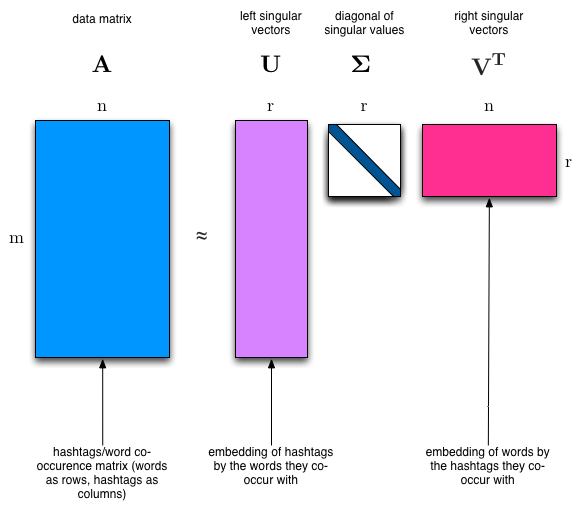

In [22]:
from IPython.display import Image, display

# Replace 'path/to/your/image.jpg' with the actual path to your image
image_path = '/content/drive/MyDrive/Teaching/Math391/svd_fb.png'
display(Image(filename=image_path))

In [23]:
A = np.array([[-1, 2], [3, -2], [5, 7]])
A

array([[-1,  2],
       [ 3, -2],
       [ 5,  7]])

In [24]:
U, d, VT = np.linalg.svd(A) # V is already transposed

In [25]:
U

array([[ 0.12708324,  0.47409506,  0.87125411],
       [ 0.00164602, -0.87847553,  0.47778451],
       [ 0.99189069, -0.0592843 , -0.11241989]])

In [26]:
VT

array([[ 0.55798885,  0.82984845],
       [-0.82984845,  0.55798885]])

In [27]:
d

array([8.66918448, 4.10429538])

In [28]:
np.diag(d)

array([[8.66918448, 0.        ],
       [0.        , 4.10429538]])

$D$ must have the same dimensions as $A$ for $UDV^T$ matrix multiplication to be possible:

In [29]:
D = np.concatenate((np.diag(d), [[0, 0]]), axis=0)
D

array([[8.66918448, 0.        ],
       [0.        , 4.10429538],
       [0.        , 0.        ]])

In [30]:
np.dot(U, np.dot(D, VT))

array([[-1.,  2.],
       [ 3., -2.],
       [ 5.,  7.]])

In [233]:
from numpy import diag, zeros,vstack
from numpy.random import rand, seed
from numpy.linalg import svd, pinv

seed (12345)

n=5
p=8
X = rand(n,p)
y = rand(n,1)
U,S,VT = svd(X)
Sigma = diag(1/S)
# compute pseudo inverse
pseudo_inv = VT.T @ vstack((Sigma, zeros((p-n,n)))) @ U.T
b = pseudo_inv @ y
#b = pinv(X) @ y #remove comment for the built-in pseudo inverse
print(X @ b - y)

[[ 4.44089210e-16]
 [ 2.22044605e-16]
 [-1.11022302e-16]
 [ 7.77156117e-16]
 [ 7.21644966e-16]]


### Image Compression via SVD

In [31]:
from PIL import Image

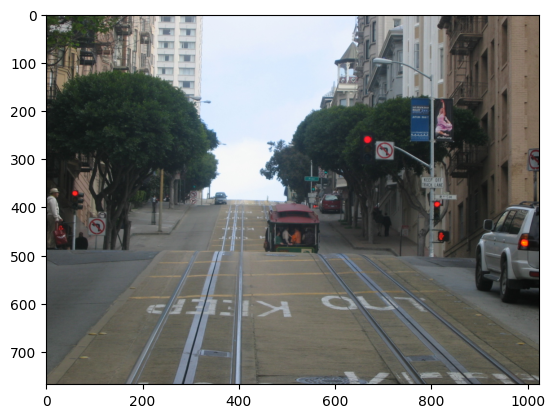

In [32]:
img = Image.open('/content/drive/MyDrive/Teaching/Math391/SanFranciscoStreet.jpg')
_ = plt.imshow(img)

Convert image to grayscale so that we don't have to deal with the complexity of multiple color channels:

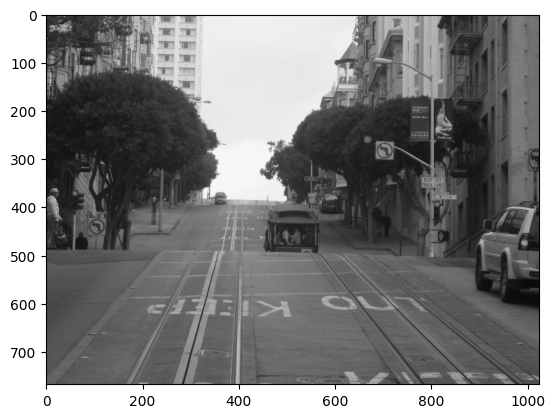

In [33]:
imggray = img.convert('LA')
_ = plt.imshow(imggray)

Convert data into numpy matrix, which doesn't impact image data:

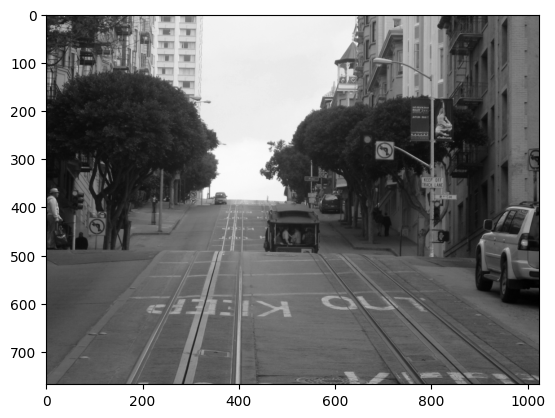

In [34]:
imgmat = np.array(list(imggray.getdata(band=0)), float)
imgmat.shape = (imggray.size[1], imggray.size[0])
imgmat = np.matrix(imgmat)
_ = plt.imshow(imgmat, cmap='gray')

Calculate SVD of the image:

In [35]:
U, Sigma, V = np.linalg.svd(imgmat)

As eigenvalues are arranged in descending order in diag($\lambda$) so too are singular values, by convention, arranged in descending order in $D$ (or, in this code, diag($\Sigma$)). Thus, the first left-singular vector of $U$ and first right-singular vector of $V$ may represent the most prominent feature of the image:

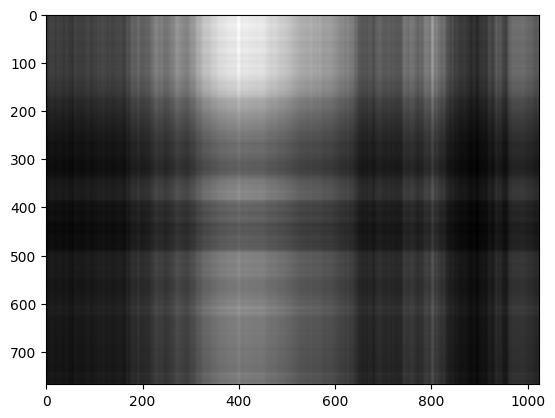

In [36]:
reconstimg = np.matrix(U[:, :1]) * np.diag(Sigma[:1]) * np.matrix(V[:1, :])
_ = plt.imshow(reconstimg, cmap='gray')

Additional singular vectors improve the image quality:

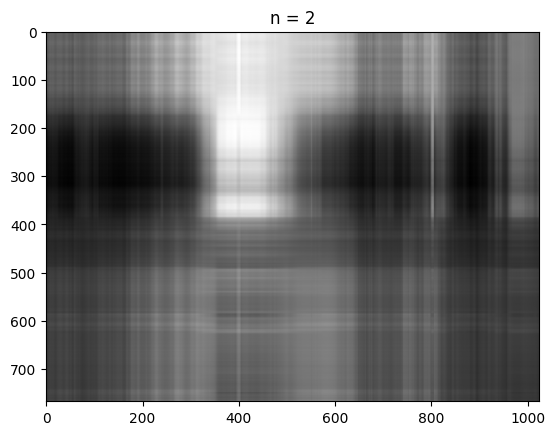

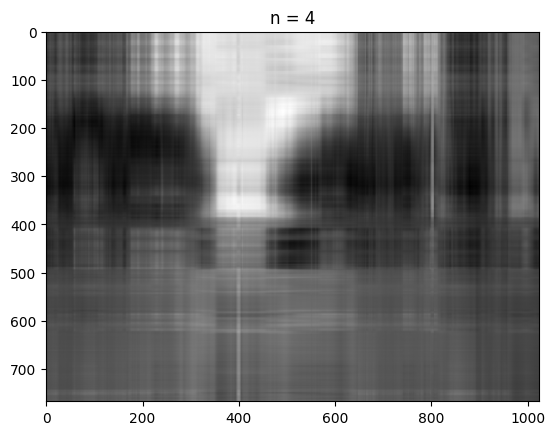

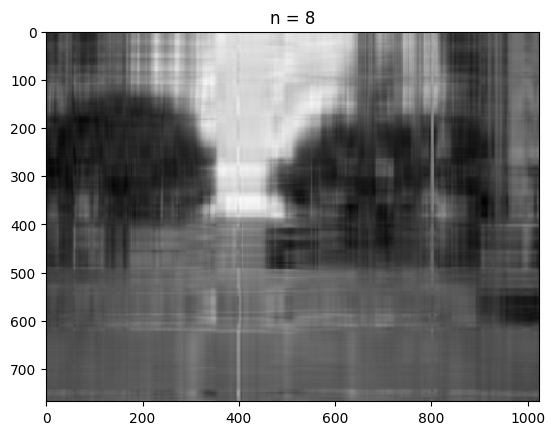

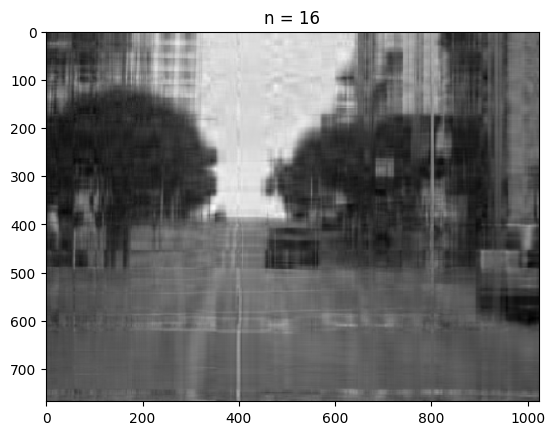

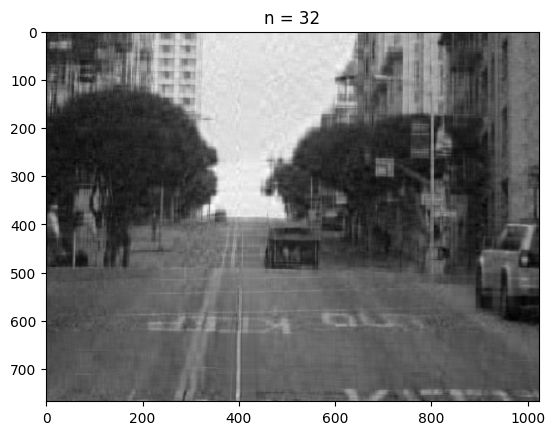

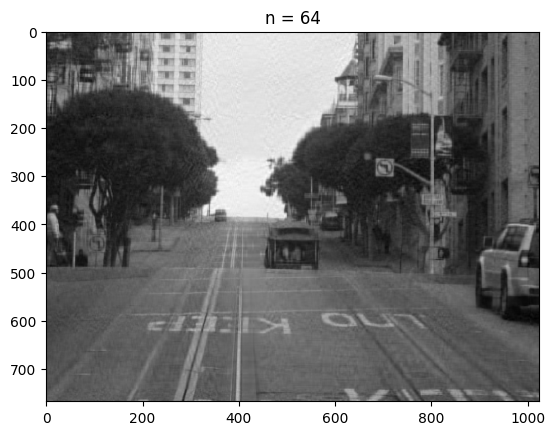

In [37]:
for i in [2, 4, 8, 16, 32, 64]:
    reconstimg = np.matrix(U[:, :i]) * np.diag(Sigma[:i]) * np.matrix(V[:i, :])
    plt.imshow(reconstimg, cmap='gray')
    title = "n = %s" % i
    plt.title(title)
    plt.show()

With 64 singular vectors, the image is reconstructed quite well, however the data footprint is much smaller than the original image:

In [38]:
imgmat.shape

(768, 1024)

In [39]:
full_representation = 4032*3024
full_representation

12192768

In [40]:
svd64_rep = 64*4032 + 64 + 64*3024
svd64_rep

451648

In [41]:
svd64_rep/full_representation

0.037042286050222556

Specifically, the image represented as 64 singular vectors is 3.7% of the size of the original!

Alongside images, we can use singular vectors for dramatic, lossy compression of other types of media files.

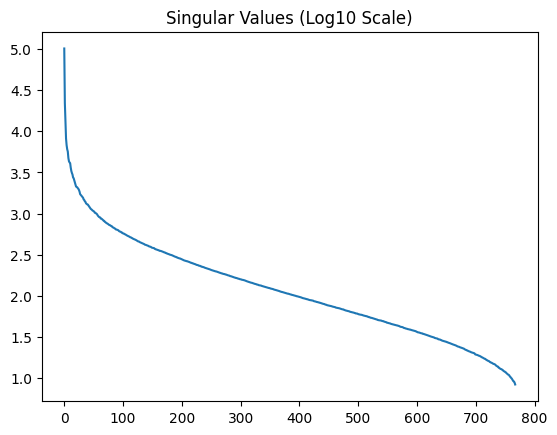

In [42]:
# Plot the magnitude of the singular values (log scale)
plt.plot(np.log10(Sigma)); plt.title('Singular Values (Log10 Scale)');

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipython-input-2856067831.py:1: SyntaxWarning: invalid escape sequence '\S'
  plt.plot(np.cumsum(Sigma) / sum(Sigma)); plt.title('Cumulative Percent of Total \Sigmas');


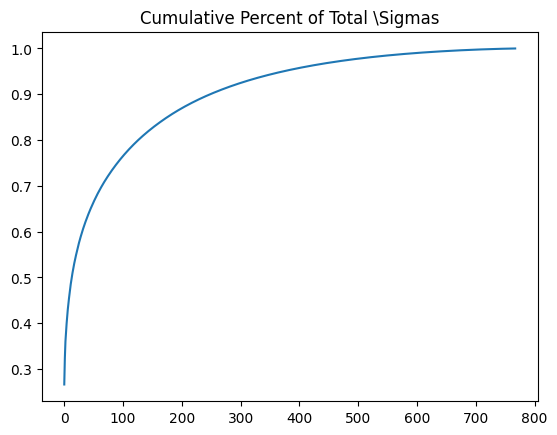

In [43]:
plt.plot(np.cumsum(Sigma) / sum(Sigma)); plt.title('Cumulative Percent of Total \Sigmas');

# 3. Background Removal with SVD

We use the real video: Human Activity Video Datasets:

Import needed libraries:

In [44]:
import moviepy.editor as mpe
# from IPython.display import display
from glob import glob

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



In [45]:
import sys, os
import numpy as np
import scipy

In [46]:
%matplotlib inline
import matplotlib.pyplot as plt

In [47]:
# MAX_ITERS = 10
TOL = 1.0e-8

In [48]:
from google.colab import drive
drive.mount('/content/drive')
import cv2

video = mpe.VideoFileClip("/content/drive/MyDrive/Teaching/Math391/Video_003.avi")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
video.subclip(0,50).ipython_display(width=300)

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


In [50]:
video.duration

113.57

### Helper Methods

In [51]:
from PIL import Image

In [52]:
def create_data_matrix_from_video(clip, k=5, scale = (160,120)):
  return np.vstack([np.array(Image.fromarray(rgb2gray(clip.get_frame(i/float(k))).astype(np.uint8)).resize(scale)).flatten()
                   for i in range(k * int(clip.duration))]).T
  #return np.vstack([scipy.misc.imresize(rgb2gray(clip.get_frame(i/float(k))).astype(int), scale).flatten() for i in range(k * int(clip.duration))]).T

In [53]:
def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.299, 0.587, 0.114])

In [54]:
def plt_images(M, A, E, index_array, dims, filename=None):
    f = plt.figure(figsize=(15, 10))
    r = len(index_array)
    pics = r * 3
    for k, i in enumerate(index_array):
        for j, mat in enumerate([M, A, E]):
            sp = f.add_subplot(r, 3, 3*k + j + 1)
            sp.axis('Off')
            pixels = mat[:,i]
            if isinstance(pixels, scipy.sparse.csr_matrix):
                pixels = pixels.todense()
            plt.imshow(np.reshape(pixels, dims), cmap='gray')
    return f

In [55]:
def plots(ims, dims, figsize=(15,20), rows=1, interp=False, titles=None):
    if type(ims[0]) is np.ndarray:
        ims = np.array(ims)
    f = plt.figure(figsize=figsize)
    for i in range(len(ims)):
        sp = f.add_subplot(rows, len(ims)//rows, i+1)
        sp.axis('Off')
        plt.imshow(np.reshape(ims[i], dims), cmap="gray")

### Load and view the data

An image from 1 moment in time is 60 pixels by 80 pixels (when scaled). We can *unroll* that picture into a single tall column. So instead of having a 2D picture that is $60 \times 80$, we have a $1 \times 4,800$ column

This isn't very human-readable, but it's handy because it lets us stack the images from different times on top of one another, to put a video all into 1 matrix.  If we took the video image every tenth of a second for 113 seconds (so 11,300 different images, each from a different point in time), we'd have a $11300 \times 4800$ matrix, representing the video!

In [56]:
scale = 25   # Adjust scale to change resolution of image
dims = (int(240 * (scale/100)), int(320 * (scale/100)))

In [57]:
M = create_data_matrix_from_video(video, 100, (80, 60))
# M = create_data_matrix_from_video(video, 100, scale)
# M = np.load("high_res_surveillance_matrix.npy")

In [58]:
print(dims, M.shape)

(60, 80) (4800, 11300)


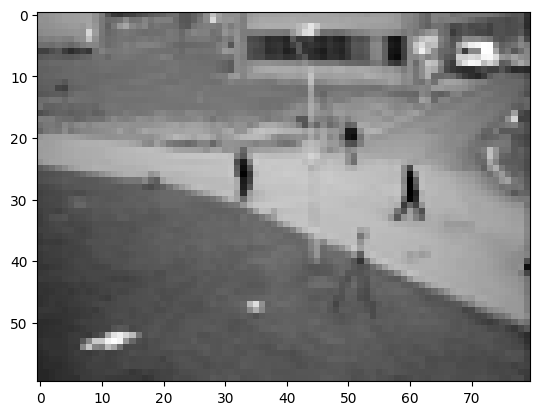

In [59]:
plt.imshow(np.reshape(M[:,140], dims), cmap='gray');

Since `create_data_from_matrix` is somewhat slow, we will save our matrix.  In general, whenever you have slow pre-processing steps, it's a good idea to save the results for future use.

In [60]:
np.save("low_res_surveillance_matrix.npy", M)

Note: High-res M is too big to plot, so only run the below with the low-res version

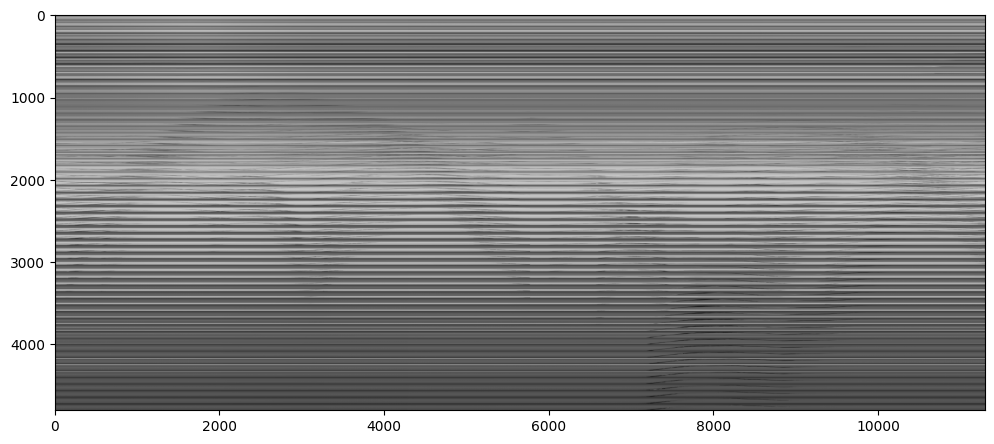

In [61]:
plt.figure(figsize=(12, 12))
plt.imshow(M, cmap='gray')

**Questions**: What are those wavy black lines?  What are the horizontal lines?

In [62]:
plt.imsave(fname="image1.jpg", arr=np.reshape(M[:,140], dims), cmap='gray')

## SVD

### A first attempt with SVD

In [63]:
from sklearn import decomposition

In [64]:
u, s, v = decomposition.randomized_svd(M, 2)

In [65]:
u.shape, s.shape, v.shape

((4800, 2), (2,), (2, 11300))

In [66]:
low_rank = u @ np.diag(s) @ v

In [67]:
low_rank.shape

(4800, 11300)

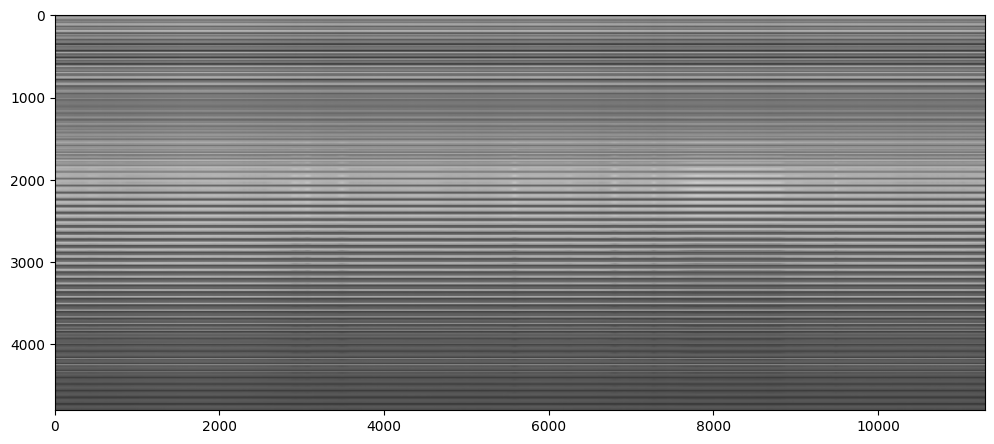

In [68]:
plt.figure(figsize=(12, 12))
plt.imshow(low_rank, cmap='gray')

The below images were created with high-res data.  Very slow to process:

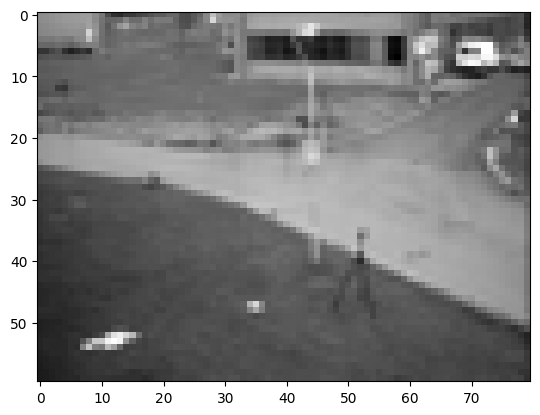

In [69]:
plt.imshow(np.reshape(low_rank[:,140], dims), cmap='gray');

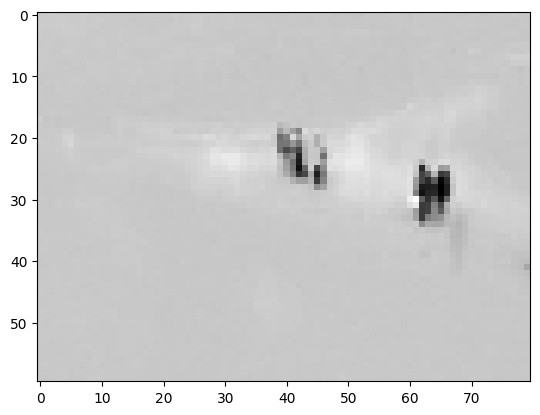

In [70]:
plt.imshow(np.reshape(M[:,550] - low_rank[:,550], dims), cmap='gray');

#### Rank 1 Approximation

In [71]:
u, s, v = decomposition.randomized_svd(M, 1)

In [72]:
u.shape, s.shape, v.shape

((4800, 1), (1,), (1, 11300))

In [73]:
low_rank = u @ np.diag(s) @ v

In [74]:
low_rank.shape

(4800, 11300)

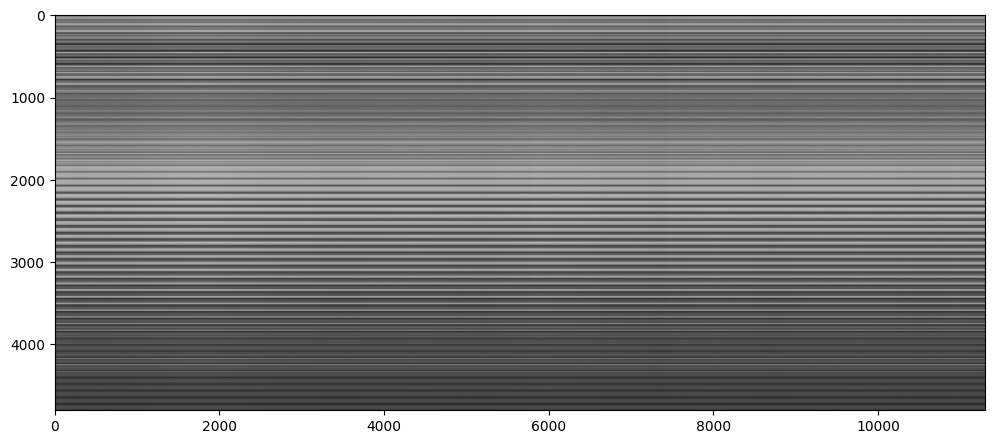

In [75]:
plt.figure(figsize=(12, 12))
plt.imshow(low_rank, cmap='gray')

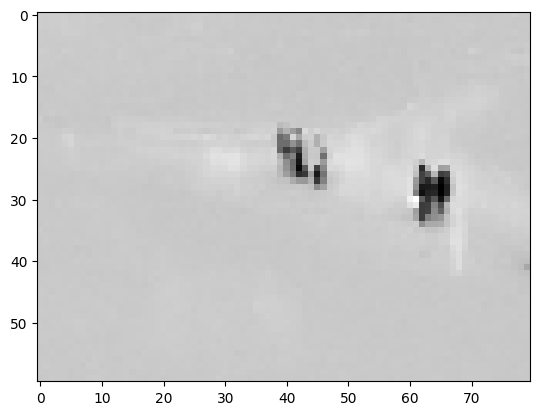

In [76]:
plt.imshow(np.reshape(M[:,550] - low_rank[:,550], dims), cmap='gray');

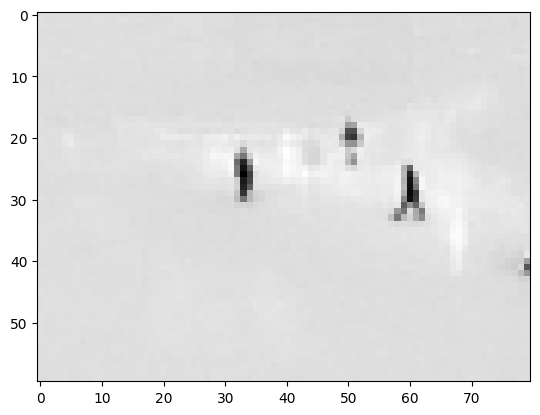

In [77]:
plt.imshow(np.reshape(M[:,140] - low_rank[:,140], dims), cmap='gray');

Let's zoom in on the people:

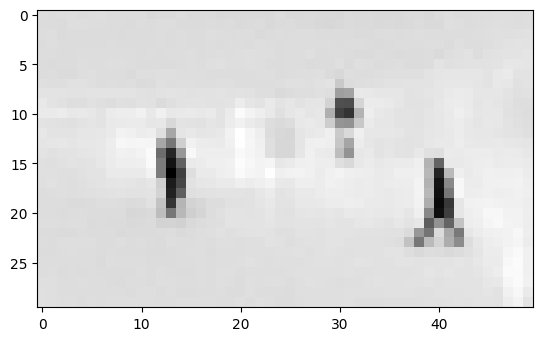

In [78]:
plt.imshow(np.reshape(M[:,140] - low_rank[:,140], dims)[10:40,20:70], cmap='gray');


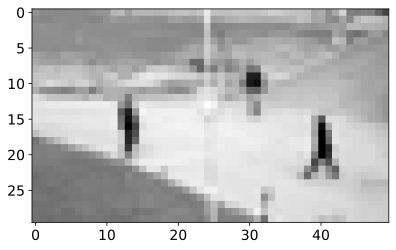

In [144]:
plt.imshow(np.reshape(M[:,140], dims)[10:40,20:70], cmap='gray')

## Exercises:









  axs[0].set_title('$\mathbf{A}$\nThe matrix')

  axs[1].set_title('$\mathbf{U}$\n(left singular vects)')

  axs[2].set_title('$\mathbf{\Sigma}$\n(singular vals)')

  axs[3].set_title('$\mathbf{V}$\n(right singular vects)')



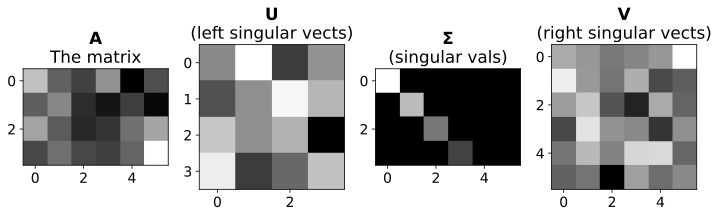

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size



A = np.random.randn(4,6)

# its SVD
U,s,Vt = np.linalg.svd(A)

# create Sigma from sigma's
S = np.zeros(np.shape(A))
np.fill_diagonal(S,s)


# show the matrices
_,axs = plt.subplots(1,4,figsize=(10,6))

axs[0].imshow(A,cmap='gray',aspect='equal')
axs[0].set_title('$\mathbf{A}$\nThe matrix')

axs[1].imshow(U,cmap='gray',aspect='equal')
axs[1].set_title('$\mathbf{U}$\n(left singular vects)')

axs[2].imshow(S,cmap='gray',aspect='equal')
axs[2].set_title('$\mathbf{\Sigma}$\n(singular vals)')

axs[3].imshow(Vt,cmap='gray',aspect='equal')
axs[3].set_title('$\mathbf{V}$\n(right singular vects)')

plt.tight_layout()
plt.savefig('Figure_14_02.png',dpi=300)
plt.show()


In [81]:
A = np.random.randn(5,5)
A = A.T@A

# extract eigenvalues and singular values
eigvals = np.linalg.eig(A)[0]
sinvals = np.linalg.svd(A)[1]

# they're the same!
print(np.sort(eigvals))
print(np.sort(sinvals))

[ 0.09313715  0.20708327  1.60070577  4.12169424 14.97053761]
[ 0.09313715  0.20708327  1.60070577  4.12169424 14.97053761]


In [82]:
# create a symmetric matrix
A = np.random.randn(5,5)
A = A.T@A
# A = A+A.T # uncomment this line to repeat for A+A'

# eigendecomposition
evals,evecs = np.linalg.eig(A)

# sorting them helps the comparison!
sidx  = np.argsort(evals)[::-1]
evals = evals[sidx]
evecs = evecs[:,sidx]



# SVD
U,s,Vt = np.linalg.svd(A)

# compare the eigenvalues and singular values
print('Eigenvalues and singular values:')
print(np.vstack((evals,s)).T)

# now compare the left and right singular vectors
print(f'\nLeft-Right singular vectors (should be zeros)')
print(np.round(U-Vt.T,10)) # remember to compare V not V^T!

# then compare singular vectors with eigenvectors
print(f'\nSingular vectors - eigenvectors (should be zeros)')
print(np.round(U-evecs,10)) # subtract and
print(' ')
print(np.round(U+evecs,10)) # add for sign indeterminancy

Eigenvalues and singular values:
[[21.98414711 21.98414711]
 [15.73692519 15.73692519]
 [ 6.52236336  6.52236336]
 [ 4.79808492  4.79808492]
 [ 0.4349997   0.4349997 ]]

Left-Right singular vectors (should be zeros)
[[ 0. -0.  0.  0.  0.]
 [ 0. -0. -0. -0. -0.]
 [ 0. -0. -0.  0.  0.]
 [ 0. -0.  0. -0.  0.]
 [ 0.  0. -0.  0.  0.]]

Singular vectors - eigenvectors (should be zeros)
[[-0.15985194  0.         -1.77426775  0.         -0.64428632]
 [ 0.5633816   0.         -0.82719277 -0.          0.5063496 ]
 [-0.10998364  0.         -0.36099033 -0.          1.41560756]
 [ 1.10937356 -0.         -0.10175512 -0.          0.86061215]
 [ 1.55378327 -0.          0.16449299  0.         -0.76413821]]
 
[[-0.         -0.57034426 -0.          0.29329826  0.        ]
 [ 0.          1.35105263  0.         -0.95740283  0.        ]
 [ 0.          0.24353581 -0.          1.33952795 -0.        ]
 [-0.         -1.28169939 -0.         -0.61280471 -0.        ]
 [ 0.          0.3837984  -0.          0.909665

In [83]:
# sizes (try tall and wide)
m = 10
n = 4

# random matrix and its economy (aka reduced) SVD
A = np.random.randn(m,n)
U,s,Vt = np.linalg.svd(A,full_matrices=False)

# print sizes
print(f'Size of A:  {A.shape}')
print(f'Size of U:  {U.shape}')
print(f"Size of V': {Vt.shape}")

Size of A:  (10, 4)
Size of U:  (10, 4)
Size of V': (4, 4)




  axs[2].set_title(f'$\Sigma$ (cond={np.linalg.cond(S):.3f})')



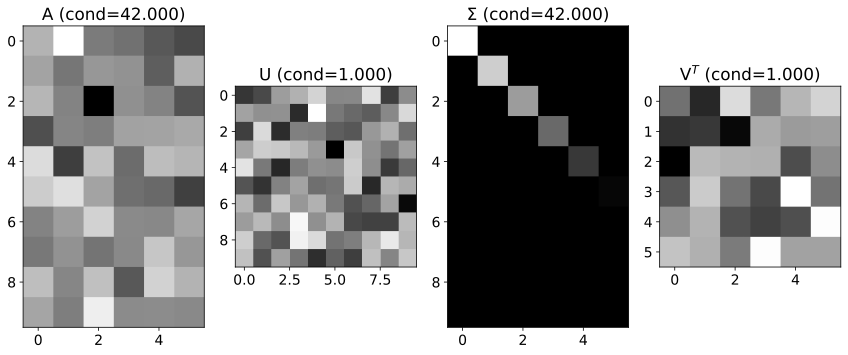

In [84]:
# create a tall matrix with specified condition number
m = 10
n = 6

condnum = 42

# create U and V from random numbers
U,_  = np.linalg.qr( np.random.randn(m,m) )
Vt,_ = np.linalg.qr( np.random.randn(n,n) )

# create singular values vector
s = np.linspace(condnum,1,np.min((m,n)))

# convert into a matrix
S = np.zeros((m,n))
np.fill_diagonal(S,s)

# create matrix
A = U@S@Vt

# and show in a plot
_,axs = plt.subplots(1,4,figsize=(12,6))

axs[0].imshow(A, aspect='equal', cmap='gray')
axs[0].set_title(f'A (cond={np.linalg.cond(A):.3f})')

axs[1].imshow(U, aspect='equal', cmap='gray')
axs[1].set_title(f'U (cond={np.linalg.cond(U):.3f})')

axs[2].imshow(S, aspect='equal', cmap='gray')
axs[2].set_title(f'$\Sigma$ (cond={np.linalg.cond(S):.3f})')

axs[3].imshow(Vt, aspect='equal', cmap='gray')
axs[3].set_title(f'V$^T$ (cond={np.linalg.cond(Vt):.3f})')


plt.tight_layout()
plt.savefig('Figure_14_04.png',dpi=300)
plt.show()



  axs[2].set_title('$\Sigma$')



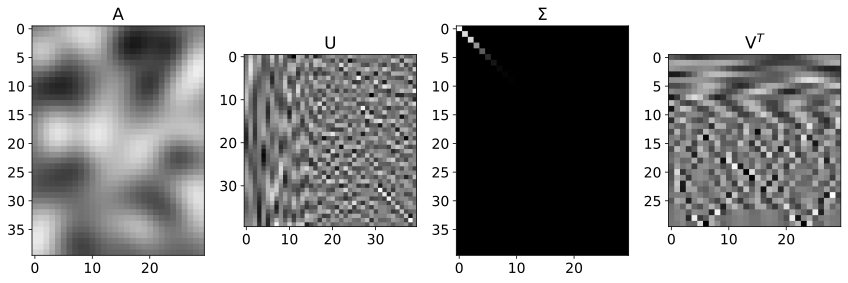

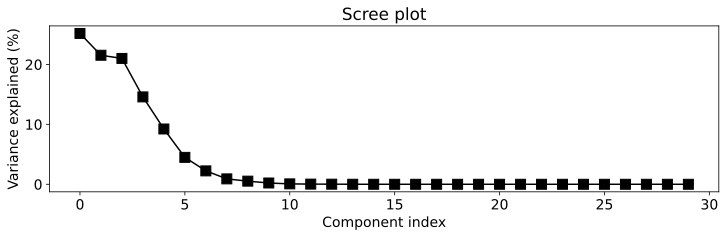

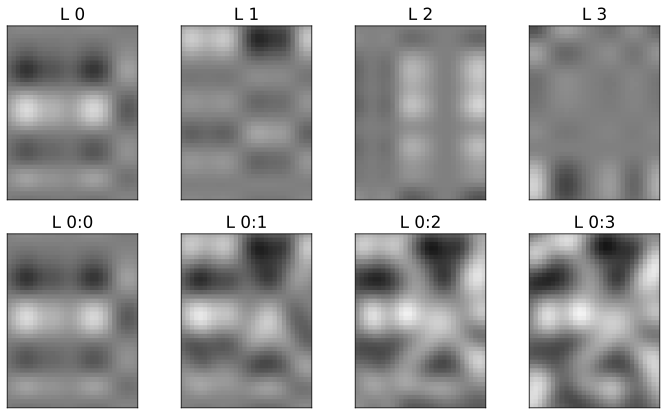

In [85]:
# create the matrix
m = 40
n = 30

# define a 2D Gaussian for smoothing
k = int((m+n)/4)
X,Y = np.meshgrid(np.linspace(-3,3,k),np.linspace(-3,3,k))
g2d = np.exp( -(X**2 + Y**2)/(k/8) )


# now for the matrix
from scipy.signal import convolve2d
A = convolve2d(np.random.randn(m,n),g2d,mode='same')


# SVD and create Sigma
U,s,Vt = np.linalg.svd(A)
S = np.zeros(np.shape(A))
np.fill_diagonal(S,s)


# visualize the matrices

# and show in a plot
_,axs = plt.subplots(1,4,figsize=(12,6))

axs[0].imshow(A, aspect='equal', cmap='gray', vmin=-10,vmax=10)
axs[0].set_title('A')

axs[1].imshow(U, aspect='equal', cmap='gray')
axs[1].set_title('U')

axs[2].imshow(S, aspect='equal', cmap='gray')
axs[2].set_title('$\Sigma$')

axs[3].imshow(Vt, aspect='equal', cmap='gray')
axs[3].set_title('V$^T$')


plt.tight_layout()
plt.savefig('Figure_14_05a.png',dpi=300)
plt.show()


# and show the scree plot
plt.figure(figsize=(12,3))
plt.plot(100*s/np.sum(s),'ks-',markersize=10)
plt.xlabel('Component index')
plt.ylabel('Variance explained (%)')
plt.title('Scree plot')
plt.savefig('Figure_14_05b.png',dpi=300)
plt.show()

## now show the first N "layers" separately and summed

numLayers = 4
rank1mats = np.zeros((numLayers,m,n))


# setup the figure
_,axs = plt.subplots(2,numLayers,figsize=(10,6))

# the loop
for i in range(numLayers):

    # create this layer
    rank1mats[i,:,:] = np.outer(U[:,i],Vt[i,:])*S[i,i]

    # show this layer
    axs[0,i].imshow(rank1mats[i,:,:],cmap='gray', vmin=-10,vmax=10)
    axs[0,i].set_title(f'L {i}')
    axs[0,i].set_xticks([]), axs[0,i].set_yticks([])

    # show the cumulative sum of layers
    axs[1,i].imshow(np.sum(rank1mats[:i+1,:,:],axis=0),cmap='gray', vmin=-10,vmax=10)
    axs[1,i].set_title(f'L 0:{i}')
    axs[1,i].set_xticks([]), axs[1,i].set_yticks([])


plt.tight_layout()
plt.savefig('Figure_14_05c.png',dpi=300)
plt.show()

# Homework

 **HW5-1:** Create a $100\times 100$ matrix of random numbers between 0 and 1
such that each entry is highly correlated with the adjacency entries. Find the SVD of the matrix. What fraction of the Frobenius norm of A is captured by the top 10 singular vectors? How many singular vectors are required to capture 95% of the Frobenius norm (the square root of the sum of the squares of all elements of the matrix)?
2. Repeat (1) with a $100\times 100$ matrix of statistically independent random numbers between 0 and 1.



In [156]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec # for the subplots

import pandas as pd
import seaborn as sns

# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size



# Create some correlated data
X = np.random.randn(100,100)
X[:,1] = np.sum(X,axis=1)

# quick PCA
evals,evecs = np.linalg.eig( np.cov(X.T,ddof=1) )
scores = X @ evecs


**HW5-2:** (Finding Structure in Movie Ratings and Consumers): The 100K MovieLens dataset available at
https://grouplens.org/datasets/movielens/100k/. There are m = 1682 movies and n = 943 users. Each user rated at least 20 movies, but some watched many more. The total dataset contains 100, 000 total ratings from all users. Compute the singular value decomposition (SVD) corresponding matrix and suggest a way to capture the relationships of how people rate movies, and especially if there is a structure linking which people like which movies. You can interpret the left-singular vectors as stereotypical movies and
the right-singular vectors as stereotypical viewers. A specific movie is therefore represented by how it decomposes (linearly) into its stereotypical movies. Likewise, a person would be represented by how they decompose (via linear combination) into movie themes.


You can then make the assumption that any viewer's specific movie preferences can be expressed as a linear combination of the $v_j$. Similarly, any movie's like-ability can be expressed as a linear combination of the $u_i$. Therefore, a vector in the domain of the SVD can be interpreted as a viewer in the “space” of stereotypical viewers, and a vector in the codomain of the SVD correspondingly as a movie in the “space” of stereotypical movies. This can be the basis for recommending movies the users haven't seen (assuming that each
user would give a rating of 0 to any movie they have not reviewed). How can you use SVD to group a type of users with a specific set of movies?   

# Quadratic form

A _quadratic form_ is a function with form $Q(\mathbf{x})=\mathbf{x}^TA\mathbf{x}$, where $A$ is an $n\times n$ (often symmetric matrix), which is called the _the matrix of the quadratic form_.

-------

Consider the following quadratic equation:


$$f({x}) = ax_1^2 +(b+c)x_1x_2 + dx_2^2$$



------


These quadratic forms can be generated by matrices:

$$ f({x})= \begin{bmatrix}
    x_1 & x_2
\end{bmatrix}\begin{bmatrix}
    a & b\\\\
    c & d
\end{bmatrix}\begin{bmatrix}
    x_1\\\\
    x_2
\end{bmatrix} = {x^\text{T}Ax}$$



Note that the same quadratic form can be obtained from infinite number of matrices $A$ by changing $b$ and $c$ while preserving their sum. We usually
consider making $A$ symmetric.

### Example

$$ {x} = \begin{bmatrix}
    x_1\\\\
    x_2
\end{bmatrix}$$

and

$$ {A}=\begin{bmatrix}
    6 & 2\\\\
    2 & 3
\end{bmatrix}$$

$$\begin{align*}
{x^\text{T}Ax}&=
\begin{bmatrix}
    x_1 & x_2
\end{bmatrix}
\begin{bmatrix}
    6 & 2\\\\
    2 & 3
\end{bmatrix}
\begin{bmatrix}
    x_1\\\\
    x_2
\end{bmatrix}\\\\
&=
\begin{bmatrix}
    x_1 & x_2
\end{bmatrix}
\begin{bmatrix}
    6 x_1 + 2 x_2\\\\
    2 x_1 + 3 x_2
\end{bmatrix}\\\\
&=
x_1(6 x_1 + 2 x_2) + x_2(2 x_1 + 3 x_2)\\\\
&=
6 x_1^2 + 4 x_1x_2 + 3 x_2^2
\end{align*}$$

If $A$
 is a diagonal matrix, the quadratic form of ${x^\text{T}Ax}$
 will have no cross term.

To convert a matrix of quadratic form into diagonal matrix, i.e. no cross products terms, consider $A$, which is symmetric, so there is an orthonormal $P$ that

$$
PDP^T = A \qquad \text{and}\qquad PP^T = I
$$

We can show that

$$
\mathbf{x}^TA\mathbf{x}=\mathbf{x}^TIAI\mathbf{x}=\mathbf{x}^TPP^TAPP^T\mathbf{x}=\mathbf{x}^TPDP^T\mathbf{x}=(P^T\mathbf{x})^TDP^T\mathbf{x}=\mathbf{y}^T D \mathbf{y}$$

where $P^T$ defined a coordinate transformation and $\mathbf{y} = P^T\mathbf{x}$.

Consider $A$

$$
A =
\left[
\begin{matrix}
6 & 2\\
2 & 3
\end{matrix}
\right]
$$

Find eigenvalue and eigenvectors:

In [241]:
A = np.array([[6,2],[2,3]]); A

array([[6, 2],
       [2, 3]])

In [242]:
D, P = np.linalg.eig(A)
D = np.diag(D); D

array([[7., 0.],
       [0., 2.]])

Test if $P$ is normalized.

In [243]:
P.T@P

array([[1., 0.],
       [0., 1.]])

We can compute $\mathbf{y}= P^T\mathbf{x}$

In [246]:
import sympy as sy;
x1, x2 = sy.symbols('x1 x2')
x = sy.Matrix([[x1], [x2]])
x

Matrix([
[x1],
[x2]])

In [248]:
def round_expr(expr, num_digits):
    return expr.xreplace({n : round(n, num_digits) for n in expr.atoms(sy.Number)})
P = round_expr(sy.Matrix(P), 4); P

Matrix([
[0.8944, -0.4472],
[0.4472,  0.8944]])

In [249]:
y = P.T*x; y

Matrix([
[ 0.8944*x1 + 0.4472*x2],
[-0.4472*x1 + 0.8944*x2]])

The transformed quadratic form $\mathbf{y}^T D \mathbf{y}$ is

In [250]:
D =  round_expr(sy.Matrix(D),4);D

Matrix([
[7.0, 0.0],
[0.0, 2.0]])

In [251]:
y1, y2 = sy.symbols('y1 y2')
y = sy.Matrix([[y1], [y2]]);y

Matrix([
[y1],
[y2]])

In [253]:
y.T*D*y

Matrix([[7.0*y1**2 + 2.0*y2**2]])

This change of variable leads to removing the cross terms in our quadratic equation. Without the cross term, it will then be easier to characterize the function and eventually optimize it (i.e finding its maximum or minimum).

# The Principal Axes

We can use $D$ to simplify our quadratic equation and remove the cross terms:

 $$ {D}=
\begin{bmatrix}
    7 & 0\\\\
    0 & 2
\end{bmatrix}$$

$$ \begin{align*}
{x^\text{T}Ax}
&=
{y^\text{T}{D} y}\\\\
&=
{y}^\text{T}
\begin{bmatrix}
    7 & 0\\\\
    0 & 2
\end{bmatrix}
{y}\\\\
&=
\begin{bmatrix}
    y_1 & y_2
\end{bmatrix}
\begin{bmatrix}
    7 & 0\\\\
    0 & 2
\end{bmatrix}
\begin{bmatrix}
    y_1\\\\
    y_2
\end{bmatrix}\\\\
&=
\begin{bmatrix}
    7y_1 +0y_2 & 0y_1 + 2y_2
\end{bmatrix}
\begin{bmatrix}
    y_1\\\\
    y_2
\end{bmatrix}\\\\
&=
7y_1^2 + 2y_2^2
\end{align*}$$


This form (without cross-term) is called the **principal axes form**.
The principal axes form can be found with
$${x^\text{T}Ax} = \lambda_1y_1^2 + \lambda_2y_2^2$$

where $λ_1$
 is the eigenvalue corresponding to the first eigenvector and $λ_2$
 the eigenvalue corresponding to the second eigenvector.

## Visualize the Quadratic Form

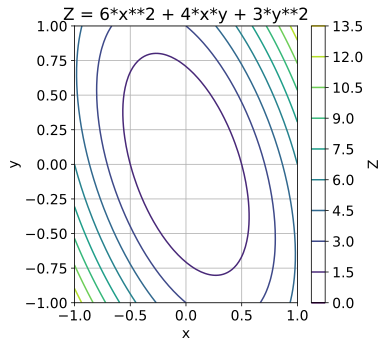

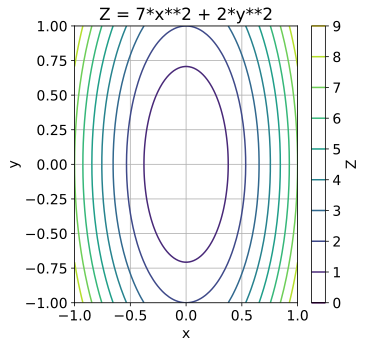

In [275]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the quadratic form function
def quadratic_form1(x, y):
    return 6*x**2 + 4*x*y + 3*y**2

def quadratic_form2(x, y):
    return 7*x**2 + 2*y**2

# 2. Create a grid of points
x_range = np.linspace(-1, 1, 100)
y_range = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(x_range, y_range)

# 3. Calculate the function values
Z1 = quadratic_form1(X, Y)
Z2 = quadratic_form2(X, Y)

# 4. Plot the contour lines
plt.figure(figsize=(5, 5))
plt.contour(X, Y, Z1, levels=10, cmap='viridis') # Plot 10 level curves

plt.colorbar(label='Z')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Z = 6*x**2 + 4*x*y + 3*y**2')
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 5))
plt.contour(X, Y, Z2, levels=10, cmap='viridis') # Plot 10 level curves

plt.colorbar(label='Z')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Z = 7*x**2 + 2*y**2')
plt.grid(True)
plt.show()

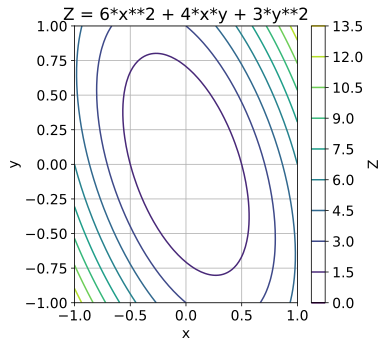

In [284]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[6,2], [2,3]])
n_points = 100

u = np.linspace(-1, 1, 100)
x, y = np.meshgrid(u, u)

X = np.vstack([x.flatten(), y.flatten()])
f_x = np.dot(np.dot(X.T, A), X)
f_x = np.diag(f_x).reshape(n_points, n_points)


plt.figure(figsize=(5, 5))
plt.contour(x, y, f_x, levels=10, cmap='viridis') # Plot 10 level curves

plt.colorbar(label='Z')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Z = 6*x**2 + 4*x*y + 3*y**2')
plt.grid(True)
plt.show()

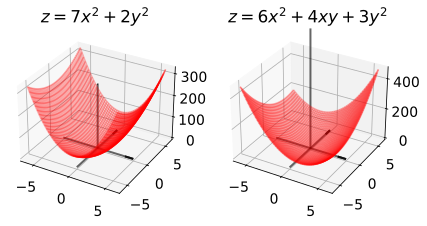

In [309]:

k = 6
x = np.linspace(-k, k)
y = np.linspace(-k, k)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize = (7, 7))

########################### xAx 1 ############################
Z = 7*X**2 + 2*Y**2
ax = fig.add_subplot(221, projection='3d')
ax.plot_wireframe(X, Y, Z, linewidth = 1.5, alpha = .3, color = 'r')
ax.set_title('$z = 7x^2+2y^2$')

xarrow = np.array([[-5, 0, 0, 10, 0, 0]])
X1, Y1, Z1, U1, V1, W1 = zip(*xarrow)
ax.quiver(X1, Y1, Z1, U1, V1, W1, length=1, normalize=False, color = 'black',
          alpha = .6, arrow_length_ratio = .12, pivot = 'tail',
          linestyles = 'solid',linewidths = 2)

yarrow = np.array([[0, -5, 0, 0, 10, 0]])
X2, Y2, Z2, U2, V2, W2 = zip(*yarrow)
ax.quiver(X2, Y2, Z2, U2, V2, W2, length=1, normalize=False, color = 'black',
          alpha = .6, arrow_length_ratio = .12, pivot = 'tail',
          linestyles = 'solid',linewidths = 2)

zarrow = np.array([[0, 0, -3, 0, 0, 300]])
X3, Y3, Z3, U3, V3, W3 = zip(*zarrow)
ax.quiver(X3, Y3, Z3, U3, V3, W3, length=1, normalize=False, color = 'black',
alpha = .6, arrow_length_ratio = .001, pivot = 'tail',
          linestyles = 'solid',linewidths = 2)

########################### xAx 2 ############################
Z = 6*X**2 + 4*X*Y + 3*Y**2
ax = fig.add_subplot(222, projection='3d')
ax.plot_wireframe(X, Y, Z, linewidth = 1.5, alpha = .3, color = 'r')
ax.set_title('$z = 6x^2 + 4xy + 3y^2$')
xarrow = np.array([[-5, 0, 0, 10, 0, 0]])
X1, Y1, Z1, U1, V1, W1 = zip(*xarrow)
ax.quiver(X1, Y1, Z1, U1, V1, W1, length=1, normalize=False, color = 'black',
          alpha = .6, arrow_length_ratio = .12, pivot = 'tail',
          linestyles = 'solid',linewidths = 2)

yarrow = np.array([[0, -5, 0, 0, 10, 0]])
X2, Y2, Z2, U2, V2, W2 = zip(*yarrow)
ax.quiver(X2, Y2, Z2, U2, V2, W2, length=1, normalize=False, color = 'black',
          alpha = .6, arrow_length_ratio = .12, pivot = 'tail',
          linestyles = 'solid',linewidths = 2)

zarrow = np.array([[0, 0, -3, 0, 0, 800]])
X3, Y3, Z3, U3, V3, W3 = zip(*zarrow)
ax.quiver(X3, Y3, Z3, U3, V3, W3, length=1, normalize=False, color = 'black',
          alpha = .6, arrow_length_ratio = .001, pivot = 'tail',
          linestyles = 'solid',linewidths = 2)

plt.show()

## Principal Component Analysis (PCA)

---

Exploratory data analysis is an approach of analyzing data sets to summarize their main characteristics. Consider data sampled from a low-dimensional space with added noise

\begin{equation}
X_i \sim U(S^k) + N(0,\sigma^2)
\end{equation}

We'll refer to the data $\{X_i\}$ as a point cloud.  Let's represent this point cloud using an $n\times d$ numpy array, where $n$ is the number of samples, and $d$ is the dimension of the space:

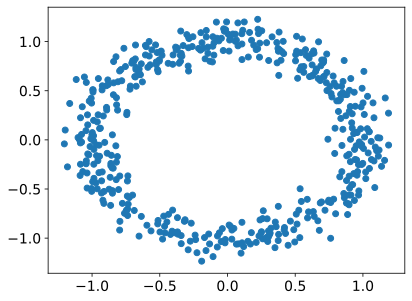

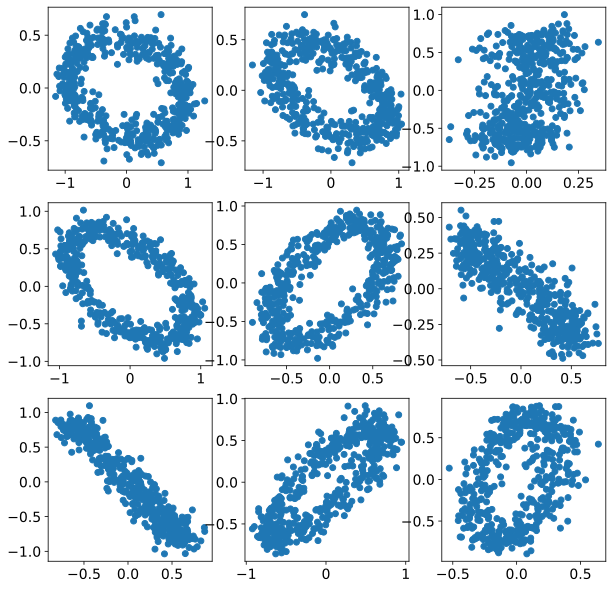

In [157]:
def sample_noisy_data(n, **kw):
    """
    Sample n points uniformly at random from the k-sphere
    embedded in d dimensions.

    Add normal nosie with variance sigma

    Arguments:
        n - number of samples

    Optional arguments:
        r - radius of circle (default 1.0)
        k - dimension of sphere (default k = 1 == circle)
        sigma - noise variance (default 0.1)
        d - dimension of embedded space (default k+1)
    """

    r = kw.get('r', 1.0)
    k = kw.get('k', 1)
    sigma = kw.get('sigma', 0.1)
    d = kw.get('d', k+1) # dimension of space

    X = np.random.randn(n,k+1) # generate random samples from standard normal distribution
    X = r * X / np.linalg.norm(X, axis=1).reshape(n,-1) # project onto sphere

    # taking the Q factor of QR factorization of random normal matrix to sample random subspaces
    Q, R = np.linalg.qr(np.random.randn(d, k+1))
    X = X @ Q.T # apply random rotation

    return X + sigma*np.random.randn(n,d)

X = sample_noisy_data(500)

plt.scatter(X[:,0], X[:,1])
plt.show()

m, n = 3,3
fig, ax = plt.subplots(m,n, figsize=(10,10))
for i in range(m):
    for j in range(n):
        X = sample_noisy_data(500, d=5)

        ax[i,j].scatter(X[:,0], X[:,1])

plt.show(fig)

In [150]:

# Plotly lets you create Javascript visualizations

import plotly
import plotly.graph_objects as go

X = sample_noisy_data(500, d=3)
fig = go.Figure(data=[go.Scatter3d(x=X[:,0], y=X[:,1], z=X[:,2],
                                   mode='markers', marker=dict(size=1))])
fig.show()

In [151]:
def quick_scatter(X):
    fig = go.Figure(data=[go.Scatter3d(x=X[:,0], y=X[:,1], z=X[:,2],
                                   mode='markers',marker=dict(size=1))])
    fig.show()

quick_scatter(X)

## Dimension Reduction

Dimensionality reduction, or dimension reduction, is the transformation of data from a high-dimensional space into a low-dimensional space so that the low-dimensional representation retains some meaningful properties of the original data, ideally close to its intrinsic dimension. It can be thought of data being sampled from a low-dimensional (parameter) space, but embedded in a high-dimensional feature space (perhaps with some noise).

Working in high-dimensional spaces can be undesirable for many reasons; raw data are often sparse as a consequence of the curse of dimensionality, and analyzing the data is usually computationally intractable.

### Principal Component Analysis (PCA)

The simplest way to reduce the dimension of real-valued data is through a linear projection.

In [152]:
X = sample_noisy_data(500, d=100, sigma=0.1)
Q, R = np.linalg.qr(np.random.randn(X.shape[1], 3))
X2 = X @ Q # a random projection isn't useful.

quick_scatter(X)

A random projection above isn't useful. PCA can be used to find the best $d$-dimensional subspace as the $d$-dimensional subspace with the largest variance in the data.

Consider an independent, identically distributed dataset, $X=\{x_1,x_2, \cdots, x_n\}$, where $x_i\in{\mathbb R}^D$, with mean 0 that possesses the data covariance matrix:
$$\hat{\Sigma} = \frac{1}{n}\sum_{i=1}^N x_ix_i^T= \frac{1}{n}X^T X$$
Note that $X$ is a $D \times N$ matrix, and $\hat{\Sigma}$ empirical covariance matrix, which is symmetric, positive semidefinite.

Let $v$ be a unit vector.  The projection onto the subspace spanned by $v$ is calculated as $X v$.  $Xv$ will also have zero mean. The variance in this 1-dimensional subspace is then
$$\sigma(v) = \frac{1}{n} (Xv)^T (Xv) = \frac{1}{n} v^T X^T X v$$

So the subspace with the largest variance is defined by the unit vector $v$ which maximizes
$$v^T (\frac{1}{n} X^T X) v = v^T \hat{\Sigma} v,$$
which can be written as the variational problem

$$
\operatorname{maximze}_{v\in \mathbb{R}^n} v^T \hat{\Sigma} v\\
\text{subject to } \|v\|_2 = 1
$$

This is the same problem as finding the largest magnitude eigenpair of $\hat{\Sigma}$, where $v$ is the eigenvector, and the eigenvalue of $v$ is $\sigma(v)$.

If we want to project into a $k+1$ dimensional space, we then find
$$
\operatorname{maximze}_{v\in \mathbb{R}^n} v^T \hat{\Sigma} v\\
\text{subject to } \|v\|_2 = 1, v^T V_k = 0
$$
where $V_k = [v_1,\dots,v_k]$ spans the optimal $k$-dimensional subspace.

This boils down to finding the largest $k+1$ dimensional eigenspace of $\hat{\Sigma}$.

The vectors $v_1,\dots, v_k$ are known as the **principal components** of $X$.

<img src="https://drive.google.com/uc?export=view&id=1Jx-VHWS9R9IIBnmKUML65Bm9UsdxP2X6" width="500">

[//]: #![](https://drive.google.com/uc?export=view&id=1Jx-VHWS9R9IIBnmKUML65Bm9UsdxP2X6)

<img src="https://drive.google.com/uc?export=view&id=1pdHwgq6dy0jKqZKY9L_Nv2diacu3h1FG" width="500">


[//]: #![](https://drive.google.com/uc?export=view&id=1pdHwgq6dy0jKqZKY9L_Nv2diacu3h1FG)

PCA as a dimensionality reduction algorithm maximizes the variance in the low-dimensional representation of the data to retain as much information as possible. We can obtain the basis of the principal subspace as the eigenvectors that are associated with the largest eigenvalues of the data covariance matrix:

$$\hat{\Sigma} = \frac{1}{n}\sum_{i=1}^N x_ix_i^T= \frac{1}{n}X^T X$$


If $X = U \Sigma V^T$ then
$$X^T X = V \Sigma^T U^T U \Sigma V^T = V \Sigma^2 V^T$$
Clearly, the right-singular vectors $V$ are the eigenvectors of $X^T X$. With this, we get that the columns of $V$ are the
eigenvectors of $XX^T$ (and therefore $\hat{\Sigma}$). Furthermore, the eigenvalues of $\hat{\Sigma}$, $\lambda_d$, are related to the singular values of $X$ by:
$$\lambda_d = \frac{\sigma^2_d}{N}$$
This relationship between the eigenvalues of $\hat{\Sigma}$ and the singular values of $X$ provides the connection between the maximum variance view and the singular value decomposition. Therefore we can perform an eigendecomposition and compute the eigenvalues and eigenvectors of $\hat{\Sigma}$ directly.
We use a singular value decomposition of $\hat{\Sigma}$, which is symmetric and factorizes into $XX^T$ (ignoring the factor N), and the eigenvalues of $\hat{\Sigma}$ are the squared singular values of $X$.

<img src="https://drive.google.com/uc?export=view&id=1mf9JeCyUEX917uXK_-aTbducFyuBkk5p" width="500">

In [161]:
def mean_center(X):
    mu = np.average(X, axis=0) # 1^T X / n
    return X - mu

def variance(X):
    n = X.shape[0]
    X = mean_center(X)
    X = X/np.std(X)
    return X.T @ X / n

def principal_vectors(X, k=3):
    Sigma = variance(X)
    lam, V = np.linalg.eigh(Sigma)
    return V[:,-k:] # eigenvalues in increasing order

def pca_projection(X, k=3):
    V = principal_vectors(X, k=k)
    return X @ V


X = sample_noisy_data(1000, d=100, sigma=0.1)

Xpca = pca_projection(X, k=3)

quick_scatter(Xpca)


#### PCA Via the SVD

In practice, you **should not** compute PCA by forming $X^T X$.  Why?  Because if $X$ is ill-conditioned, then $X^T X$ will be even more ill conditioned.

What you should do is use the SVD of $X$.  If $X = U \Sigma V^T$ then
$$X^T X = V \Sigma^T U^T U \Sigma V^T = V \Sigma^2 V^T$$
Clearly, the right-singular vectors $V$ are the eigenvectors of $X^T X$.

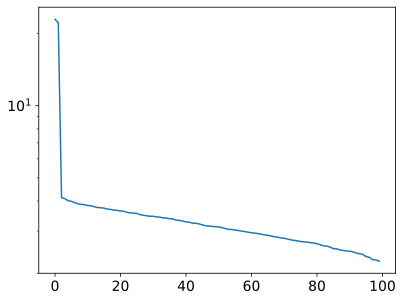

In [ ]:
X = sample_noisy_data(1000, d=100, sigma=0.1)
u, s, v = np.linalg.svd(X)
plt.semilogy(s)
plt.show()

#### HW6-1

1. Write a function to project a design matrix `X` onto its top `k` principal components using the SVD.
2. Modify your function to use `scipy.sparse.linalg.svds`.
3. What is the condition number $\kappa(X^T X)$ expressed in terms of $\kappa(X)$?
4. Plot the singular values of `X` generated above - how might you decide how many principal components to use?
5. Generate synthetic random data with a linear trend along a line and perform your PCA to find the principal components of the data.
6. Plot the original data, reconstructed data (projected data onto the principal component), along the principal components as vectors.
7. Try omitting the centering step in PCA, how do things change?
8. Add a single outlying point to your data; How do the principal components change?

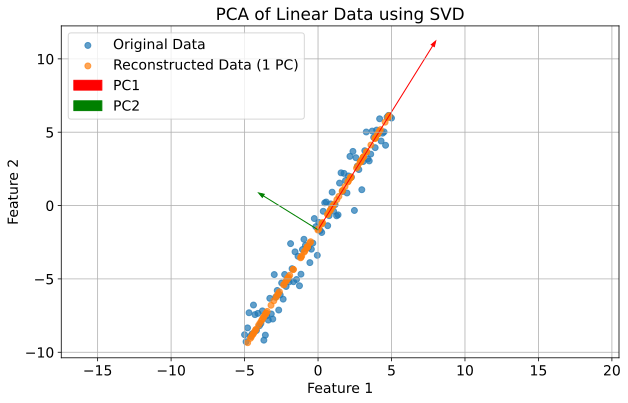

Singular values: [54.65814139  4.81560683]
Principal Components (eigenvectors of covariance matrix):
[[ 0.5281829  -0.84913063]
 [ 0.84913063  0.5281829 ]]


In [229]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate some linear data
np.random.seed(42)
# Create data that primarily varies along a diagonal line
x = np.linspace(-5, 5, 100)
y = 1.55 * (x-1) + np.random.normal(0, 1, 100) # Add some noise
data = np.vstack((x, y)).T

# Add an extra point at (-3,1) to the dataset
# data = np.vstack((data,[40,-15]))

# 2. Center the data (important for PCA)
mean_data = np.mean(data, axis=0)
centered_data = data - mean_data

# 3. Perform SVD on the centered data
# U: Left singular vectors
# s: Singular values
# Vt: Transpose of right singular vectors (V)
U, s, Vt = np.linalg.svd(centered_data, full_matrices=False)

# The right singular vectors (V) are the principal components
# Vt is already V transposed, so V is Vt.T
principal_components = Vt.T

# 4. Project the data onto the principal components (dimensionality reduction)
# We'll project onto the first principal component (the one with the largest singular value)
# This effectively reduces the 2D data to 1D along the main direction of variance.
transformed_data = centered_data @ principal_components[:, 0].reshape(-1, 1)

# 5. Reconstruct the data using the first principal component
# This shows how much variance is captured by the chosen component
reconstructed_data = transformed_data @ principal_components[:, 0].reshape(1, -1) + mean_data

# 6. Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(data[:, 0], data[:, 1], label='Original Data', alpha=0.7)
plt.scatter(reconstructed_data[:, 0], reconstructed_data[:, 1], label='Reconstructed Data (1 PC)', alpha=0.7)

# Plot the principal components as vectors from the mean
# Length of arrows: 2 standard deviations contains 95% of data
s1 = 2*np.sqrt(s[0])
s2 = 2*np.sqrt(s[1])
# Plot arrows
plt.arrow(mean_data[0],mean_data[1],s1*principal_components[0,0],s1*principal_components[1,0], head_width=0.25, color='red', label='PC1')
plt.arrow(mean_data[0],mean_data[1],s2*principal_components[0,1],s2*principal_components[1,1], head_width=0.25, color='green', label='PC2')


plt.title('PCA of Linear Data using SVD')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

print(f"Singular values: {s}")
print(f"Principal Components (eigenvectors of covariance matrix):\n{principal_components}")

#Example:

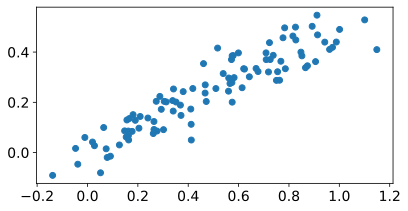

In [162]:
import numpy as np
import matplotlib.pyplot as plt

#Clean data along a line
x = np.arange(0,1,0.01)
y = x/2
X = np.vstack((x,y)).T
n = len(x)

#Add some noise
X = X + 0.05*np.random.randn(n,2)

#Plot data
plt.figure()
plt.scatter(X[:,0],X[:,1])
plt.gca().set_aspect('equal', adjustable='box')

The synthetic data is random data with a linear trend along the line $x=y$. Let's perform PCA to find the principal components of the data.

In [163]:
def pca2D(X):
    """
    PCA function for 2D data

    Args:
        X: nx2 array of data

    Returns:
        Vals = amounts of variation in each principal direction, largest first
        Mean = centroid of the data
        P = principal components of variation, as columns of matrix P
    """

    #Compute Covariance Matrix
    Mean = np.mean(X,axis=0)
    cov_matrix = (X - Mean).T@(X - Mean)/X.shape[0]

    #Compute eigenvalues Vals and eigenvectors P of covariance matrix
    Vals, P = np.linalg.eigh(cov_matrix)

    #Reverse order so largest is first
    Vals = Vals[[1,0]]
    P = P[:,[1,0]]

    return Vals, Mean, P

Vals, Mean, P = pca2D(X)

print('The principal components are the columns of the matrix')
print(P)
print('The amount of variation captured by each component is given by the eigenvalues')
print(Vals)
print(Vals[0]/(Vals[0] + Vals[1]))

The principal components are the columns of the matrix
[[-0.89905955  0.43782636]
 [-0.43782636 -0.89905955]]
The amount of variation captured by each component is given by the eigenvalues
[0.11237115 0.00284881]
0.9752750170556903


Let's plot the principal components, with length given by the amount of variation. First we'll write a function for plotting, that we will call often later on.

In [164]:
#Creates a visualization of PCA
def pca_plot(X,Vals,Mean,P,padding=0.25):
    """
    Creates a plot of 2D PCA, showing the principal component vectors
    properly scaled

    Args:
        X: Data points as mxn array
        Vals: Eigenvalues of Covariance Matrix
        Mean: Mean of data
        P: Matrix with Principal Components as columns
        padding: Fraction of padding to add to sides of plot

    Returns:
        No return, just creates plot
    """

    #Simpler variable names
    x = X[:,0]; y = X[:,1]

    #Length of arrows: 2 standard deviations contains 95% of data
    s1 = 2*np.sqrt(Vals[0])
    s2 = 2*np.sqrt(Vals[1])

    #Create large figure and scatter points
    plt.figure(figsize=(10,10))
    plt.scatter(x,y)

    #Plot arrows
    plt.arrow(Mean[0],Mean[1],s1*P[0,0],s1*P[1,0], head_width=0.025, color='red')
    plt.arrow(Mean[0],Mean[1],s2*P[0,1],s2*P[1,1], head_width=0.025, color='red')

    #Change xlim and ylim to add some extra padding to figure
    plt.xlim([x.min()-padding*(x.max()-x.min()),x.max() + padding*(x.max()-x.min())])
    plt.ylim([y.min()-padding*(y.max()-y.min()),y.max() + padding*(y.max()-y.min())])

    #Set axes to be equal units
    plt.gca().set_aspect('equal', adjustable='box')

Now let's plot the reuslts of PCA using our function.

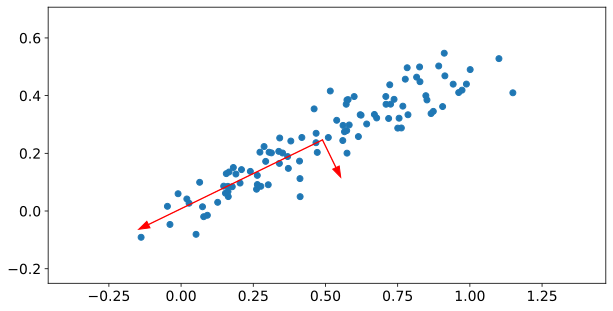

In [172]:
pca_plot(X,Vals,Mean,P)

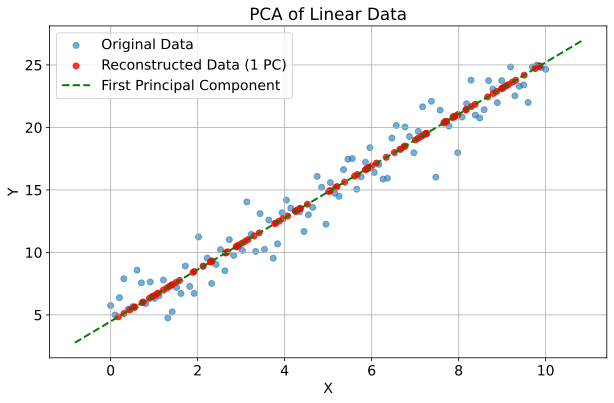

Explained variance ratio of the first principal component: 0.99


In [186]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Generate some linearly related data with noise
np.random.seed(42)
num_samples = 100
x = np.linspace(0, 10, num_samples)
y = 2 * x + 5 + np.random.normal(0, 1.5, num_samples) # Linear relationship with noise

# Combine into a 2D array for PCA
data = np.vstack((x, y)).T

# 2. Standardize the data (important for PCA)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# 3. Perform PCA
# We expect 1 significant component for this linear data
pca = PCA(n_components=1)
pca.fit(scaled_data)

# Transform the data to the principal component space
transformed_data = pca.transform(scaled_data)

# Inverse transform to visualize the effect of dimensionality reduction
# This projects the data back to the original feature space using only the principal components
reconstructed_data = pca.inverse_transform(transformed_data)

# 4. Visualize the results
plt.figure(figsize=(10, 6))

# Original data
plt.scatter(data[:, 0], data[:, 1], alpha=0.6, label='Original Data')

# Reconstructed data (projected onto the principal component)
# Need to inverse transform the scaled reconstructed data back to original scale
reconstructed_original_scale = scaler.inverse_transform(reconstructed_data)
plt.scatter(reconstructed_original_scale[:, 0], reconstructed_original_scale[:, 1],
            alpha=0.8, color='red', label='Reconstructed Data (1 PC)')

# Plot the principal component vector (scaled for visualization)
# The principal component is in the scaled data space, so we need to transform it back
# The first principal component represents the direction of maximum variance
component_vector = pca.components_[0] * pca.explained_variance_[0]**0.5 # Scale by std dev
mean_scaled_data = scaled_data.mean(axis=0)

# To visualize the principal component line, we create points along its direction
# starting from the mean of the scaled data, then inverse transform
start_point_scaled = mean_scaled_data - 2 * component_vector
end_point_scaled = mean_scaled_data + 2 * component_vector
pc_line_scaled = np.vstack((start_point_scaled, end_point_scaled))
pc_line_original_scale = scaler.inverse_transform(pc_line_scaled)

plt.plot(pc_line_original_scale[:, 0], pc_line_original_scale[:, 1],
         color='green', linestyle='--', linewidth=2, label='First Principal Component')

plt.title('PCA of Linear Data')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

# Print explained variance ratio
print(f"Explained variance ratio of the first principal component: {pca.explained_variance_ratio_[0]:.2f}")

**Robust PCA** factors a matrix into the sum of two matrices, $M = L + S$, where $M$ is the original matrix, $L$ is **low-rank**, and $S$ is **sparse**.  This is what we'll be using for the background removal problem! **Low-rank** means that the matrix has a lot of redundant information-- in this case, it's the background, which is the same in every scene (talk about redundant info!).  **Sparse** means that the matrix has mostly zero entries-- in this case, see how the picture of the foreground (the people) is mostly empty.  (In the case of corrupted data, $S$ is capturing the corrupted entries).

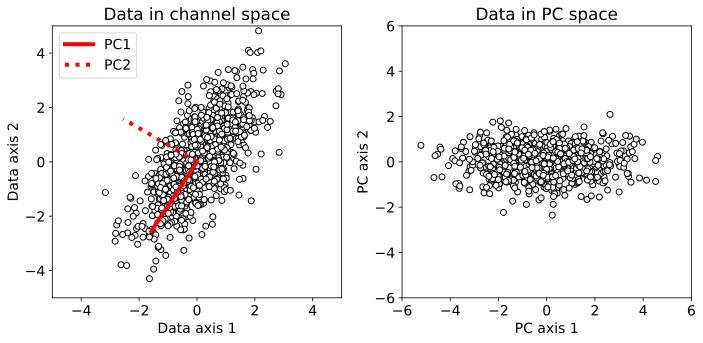

1.9060866127949094
1.9060866127949092


In [312]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec # for the subplots

import pandas as pd
import seaborn as sns

# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size



# Create some correlated data
X = np.random.randn(1000,2)
X[:,1] = np.sum(X,axis=1)

# quick PCA
evals,evecs = np.linalg.eig( np.cov(X.T,ddof=1) )
scores = X @ evecs


# show in a plot
_,axs = plt.subplots(1,2,figsize=(10,5))
axs[0].plot(X[:,0],X[:,1],'ko',markerfacecolor='w')
axs[0].plot([0,3*evecs[0,1]],[0,3*evecs[1,1]],'r-',linewidth=4,label='PC1')
axs[0].plot([0,3*evecs[0,0]],[0,3*evecs[1,0]],'r:',linewidth=4,label='PC2')
axs[0].axis([-5,5,-5,5])
axs[0].set_xlabel('Data axis 1')
axs[0].set_ylabel('Data axis 2')
axs[0].legend()
axs[0].set_title('Data in channel space')


axs[1].plot(scores[:,1],scores[:,0],'ko',markerfacecolor='w')
axs[1].set_xlabel('PC axis 1')
axs[1].set_ylabel('PC axis 2')
axs[1].axis([-6,6,-6,6])
axs[1].set_title('Data in PC space')

plt.tight_layout()
plt.savefig('Figure_15_01.png',dpi=300)
plt.show()

# Empirical demonstration that variance and squared vector norm are equal.
# You can prove their equivalence by writing down their formulas and assuming the vector is mean-centered.

# extract one variable
q = X[:,1]

# compute variance
var = np.var(q,ddof=1)

# compute squared vector norm (after mean-centering)
norm = np.linalg.norm( q-np.mean(q) )**2

# show that they're the same (with the scaling factor)
print(var)
print(norm / (len(q)-1))

## Nonlinear Dimensionality Reduction

Often linear projections are not sufficient to visualize structure in data because an embedding into parameter space is not linear.  There are a variety of techniques you can use for [nonlinear dimensionality reduction](https://en.wikipedia.org/wiki/Nonlinear_dimensionality_reduction).

These techniques often fall under the umbrella of "manifold learning" because we think if the parameter space describing the data as some manifold.

We'll use [Scikit-Learn's manifold learning module](https://scikit-learn.org/stable/modules/manifold.html) to explore these algorithms.

```bash
conda install scikit-learn
```

### Scikit-learn Syntax

Let's go over how Scikit-Learn operates.  We'll use PCA as an example.  See [the documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html).

In general, Scikit-Learn provides objects that will perform some algorithm on data.  In this case, we'll use a `PCA` object.

In [123]:
from sklearn.decomposition import PCA

In [124]:
transformer = PCA(n_components=3)
type(transformer)

sklearn.decomposition._pca.PCA

There are two stages to using a dimension reduction technique.  

First we "fit" an object (`transformer` above), to the data.  Then we can transform `X` using the object.

In [125]:
X = sample_noisy_data(1000, d=100, sigma=0.01)
transformer.fit(X)
Xpca = transformer.transform(X)

quick_scatter(Xpca)

You can also use the combined `fit_transform` method

In [126]:
Xpca = transformer.fit_transform(X)
quick_scatter(Xpca)

### Generating Nonlinear Data

Let's make our data more interesting.  First, we'll generate some nested circles

In [128]:
def nested_spheres(*rs, **kw):
    """
    generate nested circles

    Arguments:
        r1, r2, r3,... radii of circles

    Optional arguments:
        n = number of samples for each circle (default 500)
        additional arguments will be passed to sample_noisy_sphere
    """
    ns = kw.pop('n', 500) # remove key from dict
    if type(ns) is int:
        ns = tuple(ns for r in rs)

    data = []
    for n, r in zip(ns, rs):
        data.append(sample_noisy_data(n, r=r, **kw))

    return np.concatenate(data, axis=0)

np.random.seed(1)
X = nested_spheres(1.0, 2.0, 3.0, d=3)
quick_scatter(X)

In [129]:
Y = X

We can also apply a non-linear function to the data

In [130]:
def f(x):
    y = [x[0]*x[1], x[0] - x[1], np.sin(x[1]), np.cos(x[1])]
    y.extend([x[i] for i in range(2, len(x))])
    return np.array(y)

Y = np.array([f(x) for x in X])
quick_scatter(Y)

We can see PCA is a bit convoluted:

In [131]:
Ypca = PCA().fit_transform(Y)
quick_scatter(Ypca)

### Kernel PCA

[Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html)

In [132]:
from sklearn.decomposition import KernelPCA
transformer = KernelPCA(n_components=3, kernel="rbf")
Ytrans = transformer.fit_transform(Y)
quick_scatter(Ytrans)

### Isomap

In [133]:
import sklearn.manifold as manifold

In [134]:
transformer = manifold.Isomap(n_components=3)
Ytrans = transformer.fit_transform(Y)
quick_scatter(Ytrans)


The number of connected components of the neighbors graph is 4 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.



Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.




### Spectral Embedding

Spectral embeddings are computed from a graph obtained from the data.  Typically, a weighted nearest neighbors graph.

In [135]:
transformer = manifold.SpectralEmbedding(n_components=3)
Ytrans = transformer.fit_transform(Y)
quick_scatter(Ytrans)

### t-SNE

In [136]:
transformer = manifold.TSNE(n_components=3, init='pca', random_state=0)
Ytrans = transformer.fit_transform(Y)
quick_scatter(Ytrans)

### Multidimensional Scaling

Let's use a metric rather than the standard Euclidean metric

In [137]:
from scipy.spatial.distance import pdist, squareform # pairwise distances
D = squareform(pdist(Y, 'cityblock')) # L1 metric

In [138]:
transformer = manifold.MDS(n_components=3, dissimilarity="precomputed")
Ytrans = transformer.fit_transform(D)
quick_scatter(Ytrans)